In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [146]:
probes_file = '../../experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/dim_probe.csv'
probes = pd.read_csv(probes_file)
probes = probes.set_index('probe_id', drop = True)
probes['label'] = probes['isp'] + '.' + probes['city_code']
probes.head()

,label,isp,city,city_code,asn_registered,probe_ip
probe_id,,,,,,
7613,zcom.lhe,zcom,Lahore,lhe,152605,157.20.147.16
7764,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
60223,nayatel.isb,nayatel,Islamabad,isb,23674,154.192.10.60
62224,transworld.lhe,transworld,Lahore,lhe,38193,110.93.235.222
1015679,nova.lhe,nova,Lahore,lhe,136174,103.184.1.10


In [147]:
sites_file = '../../experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/dim_site.csv'
sites = pd.read_csv(sites_file)
sites = sites.set_index('site_id', drop = True)
sites.head()

,target_label,target_hostname,target_category
site_id,,,
1,Daraz,daraz.pk,ecommerce
2,Dawn,dawn.com,news
3,Dunya News,dunyanews.tv,news
4,Express,express.com.pk,news
5,FBR,fbr.gov.pk,government


In [148]:
def pat_dest(test):
    pattern = r'([\w.-]+\.[a-z.]+)\s+-\s+([\w\s]+?)\s+\(([\w\s]+)\)'
    match = re.search(pattern, test)
    if match:
        url, name, category = match.groups()
    else:
        print(f'{test} not matched')
    return (url, name, category)

def pat_time(test):
    pattern = r'\w+\s+(\d{4})-(\d{2})-(\d{1,2})t(\d{2}:\d{1,2}:\d{2})(\+\d{2}:\d{2})'
    match = re.search(pattern, test)
    if match:
        (year, month, day, time, tz) = match.groups()
    else:
        print(f'{test} not matched')
    return (year, month, day, time, tz)
    
def read_trace(f, trace_id, sites, probes):
    # The next line contains the site URL, name and category    
    next = f.readline()
    (site_url, site, category) = pat_dest(next.strip().lower())
    site_id = sites.index[sites['target_hostname'] == site_url]
    # tokens = next.split('-')
    # site_url = tokens[0].strip()
    # tokens = tokens[1].split()
    # site = tokens[0].strip()
    # category = tokens[1].strip()
    
    # The next line contains time
    next = f.readline()
    (year, month, day, time, tz) = pat_time(next.strip().lower())
    # tokens = next.split()
    # time = tokens[1]
    # tokens = tokens[1].split('T')
    # date = tokens[0]
    # time_str = tokens[1]
    
    # The next line contains source probe information
    next = f.readline()
    tokens = next.split('-')
    probe_id = tokens[0].split()[2]
    probe_asn = tokens[1].strip()
    probe_name = tokens[2].strip()
    src = probe_id
    # src = " ".join(tokens[6:])
    
    # The next line contains the destination information
    next = f.readline()
    tokens = next.split()
    dest = " ".join(tokens[1:])
    # The next line is blank
    f.readline()
    # The next line has a long --- string
    f.readline()

    tf = pd.DataFrame({'trace_id': trace_id, 'site_id': site_id,  
                       'year': year, 'month': month, 'day': day, 'time': time, 'timezone': tz, 
                      'probe_id': probe_id, 'dest': dest}, index=[0])
    # The next lines contain the traceroute hop by hop
    next = f.readline()
    # hop_numbers = []
    # hop_ips = []
    # hop_rtt = []
    hop_records = []
    while len(next) > 1:
        tokens = next.split()
        row = {
            'trace_id': trace_id,
            'hop_number': tokens[0],
            'hop_rtt': tokens[1],
            'hop_ip': tokens[2]
        }
        hop_records.append(row)
        # hop_numbers.append(tokens[0])
        # hop_rtt.append(tokens[1])
        # hop_ips.append(tokens[2])
        
        next = f.readline()
    df = pd.DataFrame(hop_records)
    # return (site, time, src, dest, hop_numbers, hop_ips, hop_rtt)
    return tf, df
    
def load_data_file(file_path, sites, probes):
    data = []
    trace_id = 0
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            master_hops = []
            master_trace_ids = []
            # The first line contains the header. Skip it
            f.readline()
            # The second line contains the number of traces. Save it somewhere
            next = f.readline()
            tokens = next.split()
            count = tokens[0]
            # The next line is blank
            f.readline()
            # The next line has a long ==== string
            f.readline()
            done = False
            while not done:
                tf, df = read_trace(f, trace_id, sites, probes)
                master_hops.append(df)
                master_trace_ids.append(tf)
                # data.append(tup)
                trace_id += 1
                if not f.readline():
                    done = True
            # 1. Use pd.concat for the list of hop dataframes
            df_hops = pd.concat(master_hops, ignore_index=True) if master_hops else pd.DataFrame()
            
            # 2. Use pd.concat for the trace metadata dataframes too (since they are now 2D with index=[0])
            df_traces = pd.concat(master_trace_ids, ignore_index=True) if master_trace_ids else pd.DataFrame()
                
    except Exception as e:
        print(f"Error reading file in background thread: {e}")
    df_traces = df_traces.set_index('trace_id', drop=True)
    return df_traces, df_hops

file_path = '../../experiments/03_longitudinal_routing/results/run_20260612_48h/routes_20260616_142719.txt'
df_traces, df_hops = load_data_file(file_path, sites, probes)

In [149]:
df_traces['site_id'] = df_traces['site_id'].astype(int)
df_traces['year'] = df_traces['year'].astype(int)
df_traces['month'] = df_traces['month'].astype(int)
df_traces['day'] = df_traces['day'].astype(int)
df_traces['probe_id'] = df_traces['probe_id'].astype(int)
df_traces.head()

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...


In [150]:
df_hops['trace_id'] = df_hops['trace_id'].astype(int)
df_hops['hop_number'] = df_hops['hop_number'].astype(int)
# df_hops['hop_rtt'] = df_hops['hop_rtt'].astype(float)
df_hops[df_hops['trace_id'] == 0]

,trace_id,hop_number,hop_rtt,hop_ip
0,0,1,1.2,203.135.63.1
1,0,2,0.4,172.25.3.14
2,0,3,*,(no
3,0,4,*,(no
4,0,5,*,(no
5,0,6,*,(no
6,0,7,*,(no
7,0,255,104.2,47.246.167.168


In [151]:
hops_by_trace_id = df_hops.groupby('trace_id')
hops_by_trace_id['hop_number'].max()

trace_id
0        255
1        255
2         12
3        255
4        255
        ... 
14314    255
14315    255
14316      7
14317      9
14318     11
Name: hop_number, Length: 14319, dtype: int64

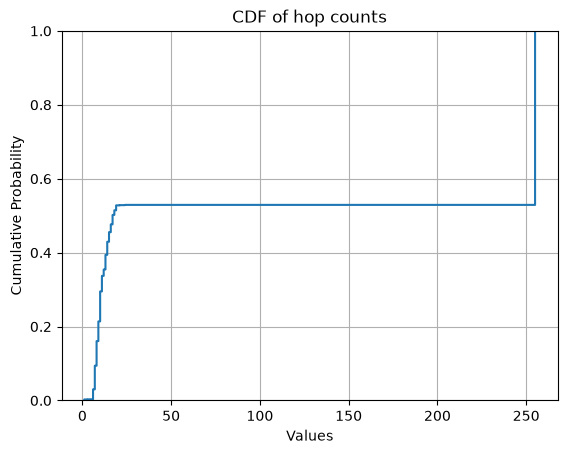

In [152]:
data_series = hops_by_trace_id['hop_number'].max()
plt.ecdf(data_series, label="Empirical CDF of hop count")

# Add styling and labels
plt.title("CDF of hop counts")
plt.xlabel("Values")
plt.ylabel("Cumulative Probability")
plt.grid(True)
# plt.legend()
plt.show()

Nearly half of our traceroutes didn't get a final reply

<Axes: >

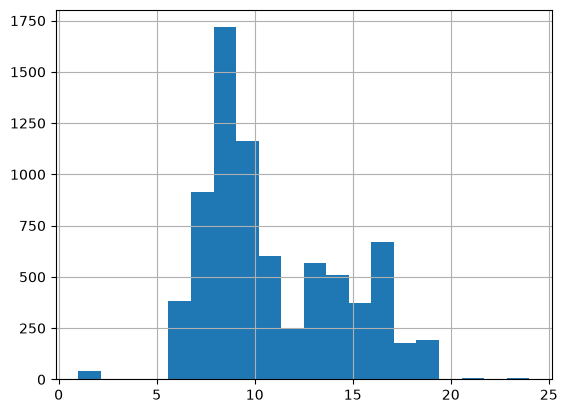

In [153]:
data_series[data_series < 255].hist(bins=20)

Most of our traces that get a final reply have a hop count between 6 and 11. There are a few very short paths, and a few long (> 20 hops) paths

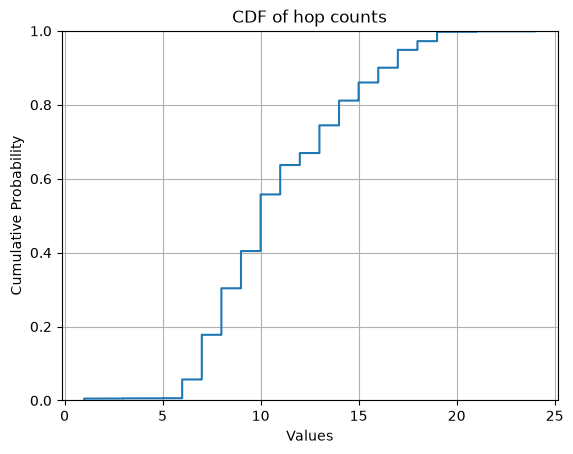

In [154]:
fin_data_series = data_series[data_series < 255]
plt.ecdf(fin_data_series, label="Empirical CDF of hop count for traces with final reply")

# Add styling and labels
plt.title("CDF of hop counts")
plt.xlabel("Values")
plt.ylabel("Cumulative Probability")
plt.grid(True)
# plt.legend()
plt.show()

What is that really short path?

In [155]:
df_max_hops = hops_by_trace_id['hop_number'].max().reset_index()
df_max_hops[df_max_hops['hop_number'] == 1]

,trace_id,hop_number
1139,1139,1
1146,1146,1
1153,1153,1
2567,2567,1
2574,2574,1
2581,2581,1
2588,2588,1
4001,4001,1
4008,4008,1
4015,4015,1


In [156]:
locations = df_max_hops[df_max_hops['hop_number'] == 1]['trace_id']
df_traces.loc[locations].merge(sites, left_on = 'site_id', right_on='site_id').merge(probes, left_on='probe_id', right_on='probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,1,2026,6,16,03:55:29,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
1,1,2026,6,16,04:10:36,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
2,1,2026,6,16,04:25:37,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
3,2,2026,6,16,03:43:31,+00:00,7764,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
4,2,2026,6,16,03:58:23,+00:00,7764,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
5,2,2026,6,16,04:13:26,+00:00,7764,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
6,2,2026,6,16,04:28:27,+00:00,7764,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
7,3,2026,6,16,03:46:43,+00:00,7764,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...,Dunya News,dunyanews.tv,news,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
8,3,2026,6,16,04:01:33,+00:00,7764,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...,Dunya News,dunyanews.tv,news,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
9,3,2026,6,16,04:16:43,+00:00,7764,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...,Dunya News,dunyanews.tv,news,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50


In [157]:
df_traces

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."


I checked one of the actual traces from my filtering application, and found that it had a "No destination" on the first hop. Need to filter that out.

In [158]:
df_hops

,trace_id,hop_number,hop_rtt,hop_ip
0,0,1,1.2,203.135.63.1
1,0,2,0.4,172.25.3.14
2,0,3,*,(no
3,0,4,*,(no
4,0,5,*,(no
...,...,...,...,...
152014,14318,7,96.1,223.120.23.5
152015,14318,8,95.3,162.158.160.111
152016,14318,9,92.7,172.69.117.60
152017,14318,10,102.3,172.69.117.67


In [159]:
hops_by_trace_id.sample()

,trace_id,hop_number,hop_rtt,hop_ip
5,0,6,*,(no
17,1,10,*,(no
27,2,8,79.8,198.11.129.113
39,3,8,*,(no
46,4,4,25.7,10.253.4.40
...,...,...,...,...
151979,14314,4,*,(no
151987,14315,4,*,(no
151994,14316,3,4.7,10.15.15.122
152006,14317,8,23.7,103.213.109.251


In [160]:
hops_by_trace_id['hop_number'] == '2'

False

In [161]:
max_indices = hops_by_trace_id['hop_number'].idxmax()

In [162]:
df_traces.index.dtype

dtype('int64')

In [163]:
max_indices

trace_id
0             7
1            19
2            31
3            42
4            56
          ...  
14314    151983
14315    151991
14316    151998
14317    152007
14318    152018
Name: hop_number, Length: 14319, dtype: int64

In [164]:
df_traces

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."


In [165]:
max_indices.index

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       14309, 14310, 14311, 14312, 14313, 14314, 14315, 14316, 14317, 14318],
      dtype='int64', name='trace_id', length=14319)

In [166]:
df_traces.loc[max_indices.index]

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."


In [167]:
df_traces.loc[max_indices.index].merge(sites, on='site_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce
...,...,...,...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",Telemart,telemart.pk,ecommerce
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",Telemart,telemart.pk,ecommerce
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",Telemart,telemart.pk,ecommerce
14317,10,2026,6,16,14:15:05,+00:00,1016036,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",Telemart,telemart.pk,ecommerce


In [168]:
max = hops_by_trace_id['hop_number'].max()

In [169]:
two_hop_trace_ids = max[max == 2].index

In [170]:
df_traces.loc[two_hop_trace_ids]

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
2019,2,2026,6,15,08:41:59,+00:00,60223,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc..."
3449,3,2026,6,15,08:43:37,+00:00,60223,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...


In [171]:
df_traces.loc[two_hop_trace_ids].merge(sites, on='site_id').merge(probes, on = 'probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,2,2026,6,15,08:41:59,+00:00,60223,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,nayatel.isb,nayatel,Islamabad,isb,23674,154.192.10.60
1,3,2026,6,15,08:43:37,+00:00,60223,202.142.167.148 - MULTINET-AS-AP - Multinet Pa...,Dunya News,dunyanews.tv,news,nayatel.isb,nayatel,Islamabad,isb,23674,154.192.10.60


On June 15, 2026, the Nayatel probe traced dawn.com. On hop 1, no reply, on hop 2, reply from 192.168.18.1 with an RTT of 1.2ms. Same for the dunyanews.tv thing. At other times, we had a "no destination" for the dunya news website, and an 8 hop response for the dawn website.

In [172]:
three_hop_trace_ids = max[max == 3].index
df_traces.loc[three_hop_trace_ids].merge(sites, on='site_id').merge(probes, on = 'probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,7,2026,6,15,08:42:55,+00:00,60223,"45.60.109.176 - INCAPSULA - Incapsula Inc, US ...",HBL Bank,hbl.com,banking,nayatel.isb,nayatel,Islamabad,isb,23674,154.192.10.60
1,7,2026,6,16,03:40:47,+00:00,7764,"45.60.109.176 - INCAPSULA - Incapsula Inc, US ...",HBL Bank,hbl.com,banking,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
2,9,2026,6,16,03:40:49,+00:00,7764,2.19.193.138 - AKAMAI-ASN1 - Akamai Internatio...,NADRA,nadra.gov.pk,government,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50


The HBL website was reachable from Nayatel ISB probe at a hop count of 3 on June 15, at 8:42 am with an RTT of 1.3 ms. But, at other times, it was reachable at a hop count of 19. HBL from LUMS Anchor also showed variations. Most of the time it got 255 TTL, but once, it got a three hop count 455.1 ms RTT, and once also got a 1 hop no destination reply. Similar behavior for NADRA website from the LUMS anchor.

In [173]:
four_hop_trace_ids = max[max == 4].index
df_traces.loc[four_hop_trace_ids].merge(sites, on='site_id').merge(probes, on = 'probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,10,2026,6,15,08:43:08,+00:00,60223,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",Telemart,telemart.pk,ecommerce,nayatel.isb,nayatel,Islamabad,isb,23674,154.192.10.60


On June 15, 8:43 am, Nayatel probe had three hop no replies, followed by a fourth hop response with an RTT of 1.4ms. At other times, it had an 8 hop count reply of around 3 ms. The sixth hop (172.31.5.106) always had an unusually high RTT.

In [174]:
five_hop_trace_ids = max[max == 5].index
df_traces.loc[five_hop_trace_ids].merge(sites, on='site_id').merge(probes, on = 'probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,1,2026,6,16,03:40:36,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,Daraz,daraz.pk,ecommerce,ptcl.lhe,ptcl,Lahore,lhe,17557,203.135.63.50
1,6,2026,6,15,08:41:32,+00:00,60223,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",Geo TV,geo.tv,news,nayatel.isb,nayatel,Islamabad,isb,23674,154.192.10.60


The Daraz five hop trace had a "no destination". The Geo trace had four hop no replies, followed by a fifth hop reached. At other times, the trace was 8 hops.

In [175]:
six_hop_trace_ids = max[max == 6].index
df_traces.loc[six_hop_trace_ids].merge(sites, on='site_id').merge(probes, on = 'probe_id')

,site_id,year,month,day,time,timezone,probe_id,dest,target_label,target_hostname,target_category,label,isp,city,city_code,asn_registered,probe_ip
0,2,2026,6,14,14:30:06,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,zcom.lhe,zcom,Lahore,lhe,152605,157.20.147.16
1,2,2026,6,14,14:45:13,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,zcom.lhe,zcom,Lahore,lhe,152605,157.20.147.16
2,2,2026,6,14,15:00:14,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,zcom.lhe,zcom,Lahore,lhe,152605,157.20.147.16
3,2,2026,6,14,15:15:16,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,zcom.lhe,zcom,Lahore,lhe,152605,157.20.147.16
4,2,2026,6,14,15:30:14,+00:00,7613,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",Dawn,dawn.com,news,zcom.lhe,zcom,Lahore,lhe,152605,157.20.147.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,6,2026,6,16,13:14:05,+00:00,7613,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",Geo TV,geo.tv,news,zcom.lhe,zcom,Lahore,lhe,152605,157.20.147.16
380,6,2026,6,16,13:29:02,+00:00,7613,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",Geo TV,geo.tv,news,zcom.lhe,zcom,Lahore,lhe,152605,157.20.147.16
381,6,2026,6,16,13:44:04,+00:00,7613,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",Geo TV,geo.tv,news,zcom.lhe,zcom,Lahore,lhe,152605,157.20.147.16
382,6,2026,6,16,13:59:02,+00:00,7613,"104.16.219.243 - CLOUDFLARENET - Cloudflare, I...",Geo TV,geo.tv,news,zcom.lhe,zcom,Lahore,lhe,152605,157.20.147.16


There are a lot of these, so these might be mostly legitimate. 

It appears that all paths with a hop count of less than six are erroneous data values.

In [176]:
df_traces

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."


In [177]:
df_hops

,trace_id,hop_number,hop_rtt,hop_ip
0,0,1,1.2,203.135.63.1
1,0,2,0.4,172.25.3.14
2,0,3,*,(no
3,0,4,*,(no
4,0,5,*,(no
...,...,...,...,...
152014,14318,7,96.1,223.120.23.5
152015,14318,8,95.3,162.158.160.111
152016,14318,9,92.7,172.69.117.60
152017,14318,10,102.3,172.69.117.67


In [178]:
# max_hop_num_for_trace = df_hops[df_hops['trace_id'] == 0]['hop_number'].max()
max_hop_indices = df_hops.groupby('trace_id')['hop_number'].idxmax()
df_max_hops = df_hops.loc[max_hop_indices]

In [179]:
df_max_hops

,trace_id,hop_number,hop_rtt,hop_ip
7,0,255,104.2,47.246.167.168
19,1,255,180.1,47.246.167.168
31,2,12,80.7,47.246.167.168
42,3,255,98.4,47.246.167.168
56,4,255,116.7,47.246.167.168
...,...,...,...,...
151983,14314,255,97.7,172.67.195.207
151991,14315,255,*,(no
151998,14316,7,4.8,172.67.195.207
152007,14317,9,23.2,172.67.195.207


In [180]:
timed_out_ids = df_max_hops[df_max_hops['hop_ip'] == '(no']['trace_id']
timed_out_ids

98            8
642          56
823          72
913          80
1186        104
          ...  
151674    14280
151738    14287
151802    14294
151930    14308
151991    14315
Name: trace_id, Length: 3606, dtype: int64

In [181]:
df_traces['is_timeout'] = df_traces.index.isin(timed_out_ids)
df_traces.sample(20)

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout
trace_id,,,,,,,,,
12987,10,2026,6,14,17:29:54,+00:00,1016036,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False
11390,8,2026,6,16,12:00:31,+00:00,1016036,"192.124.249.159 - SUCURI-SEC - Sucuri, US - US...",False
2409,2,2026,6,15,22:11:16,+00:00,1016126,"172.67.72.98 - CLOUDFLARENET - Cloudflare, Inc...",False
14020,10,2026,6,16,03:43:07,+00:00,60223,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False
6716,5,2026,6,15,22:26:25,+00:00,7764,103.125.60.60 - FBR-AS-AP - Federal Board of R...,True
8845,7,2026,6,14,22:15:18,+00:00,1016126,"45.60.109.176 - INCAPSULA - Incapsula Inc, US ...",False
4709,4,2026,6,15,03:15:18,+00:00,62224,"172.67.174.102 - CLOUDFLARENET - Cloudflare, I...",False
4519,4,2026,6,14,21:16:24,+00:00,1016143,"172.67.174.102 - CLOUDFLARENET - Cloudflare, I...",False
11378,8,2026,6,16,11:40:50,+00:00,1016126,"192.124.249.159 - SUCURI-SEC - Sucuri, US - US...",False


In [182]:
df_traces.loc[8]

site_id                                                       1
year                                                       2026
month                                                         6
day                                                          14
time                                                   14:40:30
timezone                                                 +00:00
probe_id                                                   7764
dest          47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
is_timeout                                                 True
Name: 8, dtype: object

In [183]:
df_traces[df_traces['is_timeout'] == False]

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout
trace_id,,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False
...,...,...,...,...,...,...,...,...,...
14313,10,2026,6,16,14:12:57,+00:00,60223,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False


In [184]:
!pip install seaborn

65827.91s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


<Axes: xlabel='site_id', ylabel='probe_id'>

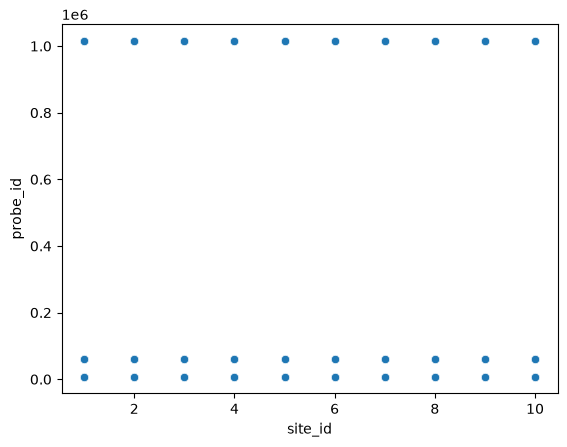

In [185]:
import seaborn as sns
sns.scatterplot(df_traces[['site_id', 'probe_id', 'is_timeout']], x = df_traces['site_id'], y=df_traces['probe_id'])

In [186]:
df_traces[df_traces['is_timeout']]['probe_id'].unique()

array([   7764, 1016036,    7613,   62224,   60223, 1016143, 1015679,
       1016126])

In [187]:
df_traces[df_traces['is_timeout']]['site_id'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

The above shows the timeouts happened from all probes at different times and for all sites, so not one is to blame.

In [188]:
untimed_out_traces = df_traces[df_traces['is_timeout'] == False]

In [189]:
max_hop_indices

trace_id
0             7
1            19
2            31
3            42
4            56
          ...  
14314    151983
14315    151991
14316    151998
14317    152007
14318    152018
Name: hop_number, Length: 14319, dtype: int64

In [190]:
max_hop_values = df_hops.groupby('trace_id')['hop_number'].max()
max_hop_values
max_hop_df = max_hop_values.to_frame(name='max_hops')

In [191]:
df_hops[df_hops['trace_id'] == 0]

,trace_id,hop_number,hop_rtt,hop_ip
0,0,1,1.2,203.135.63.1
1,0,2,0.4,172.25.3.14
2,0,3,*,(no
3,0,4,*,(no
4,0,5,*,(no
5,0,6,*,(no
6,0,7,*,(no
7,0,255,104.2,47.246.167.168


In [192]:
df_traces = df_traces.merge(max_hop_df, left_index = True, right_index = True, how='left')
df_traces

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,12
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
...,...,...,...,...,...,...,...,...,...,...
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,255
14315,10,2026,6,16,14:14:31,+00:00,7764,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",True,255
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,7


In [193]:
df_complete_traces = df_traces[df_traces['is_timeout'] == False]
df_complete_traces

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
0,1,2026,6,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
1,1,2026,6,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,12
3,1,2026,6,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
4,1,2026,6,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,255
...,...,...,...,...,...,...,...,...,...,...
14313,10,2026,6,16,14:12:57,+00:00,60223,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,8
14314,10,2026,6,16,14:13:06,+00:00,62224,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,255
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,7


In [194]:
df_complete_traces_true_hops = df_complete_traces[df_complete_traces['max_hops'] < 255]
df_complete_traces_true_hops

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
2,1,2026,6,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,12
11,1,2026,6,14,14:43:35,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,11
17,1,2026,6,14,14:56:04,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,12
19,1,2026,6,14,14:58:36,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,11
20,1,2026,6,14,14:58:36,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...,False,14
...,...,...,...,...,...,...,...,...,...,...
14312,10,2026,6,16,14:12:04,+00:00,7613,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,10
14313,10,2026,6,16,14:12:57,+00:00,60223,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,8
14316,10,2026,6,16,14:15:04,+00:00,1016143,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,7


Site ID 10 for probe ID 1015679, June 14 3 pm to 6 pm, then 6 pm to June 15 12 pm. June 15 2 pm to 6 pm.

In [195]:
site_id = 10
probe_id = 1015679
mask = (df_complete_traces_true_hops['site_id'] == site_id) & (df_complete_traces_true_hops['probe_id'] == 1015679)
case1_traces = df_complete_traces_true_hops[mask]
case1_traces

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
12894,10,2026,6,14,14:31:28,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12901,10,2026,6,14,14:46:29,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12909,10,2026,6,14,15:01:19,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12918,10,2026,6,14,15:16:27,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12925,10,2026,6,14,15:31:23,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
...,...,...,...,...,...,...,...,...,...,...
14289,10,2026,6,16,13:16:30,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
14297,10,2026,6,16,13:31:31,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
14303,10,2026,6,16,13:46:32,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11


In [196]:
spike1 = case1_traces[(case1_traces['day'] == 14) & (case1_traces['time'] >= "15:00:00") & (case1_traces['time'] <= "18:00:00")]

In [197]:
non_spike = case1_traces[(case1_traces.index > 12997) & (case1_traces['day'] == 15) & (case1_traces['time'] <= '18:00:00')]
non_spike

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
13197,10,2026,6,15,00:01:27,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13206,10,2026,6,15,00:16:32,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13214,10,2026,6,15,00:31:33,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13222,10,2026,6,15,00:46:32,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13229,10,2026,6,15,01:01:28,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
...,...,...,...,...,...,...,...,...,...,...
13716,10,2026,6,15,16:46:31,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13722,10,2026,6,15,17:01:20,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
13729,10,2026,6,15,17:16:20,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11


In [198]:
df_hops

,trace_id,hop_number,hop_rtt,hop_ip
0,0,1,1.2,203.135.63.1
1,0,2,0.4,172.25.3.14
2,0,3,*,(no
3,0,4,*,(no
4,0,5,*,(no
...,...,...,...,...
152014,14318,7,96.1,223.120.23.5
152015,14318,8,95.3,162.158.160.111
152016,14318,9,92.7,172.69.117.60
152017,14318,10,102.3,172.69.117.67


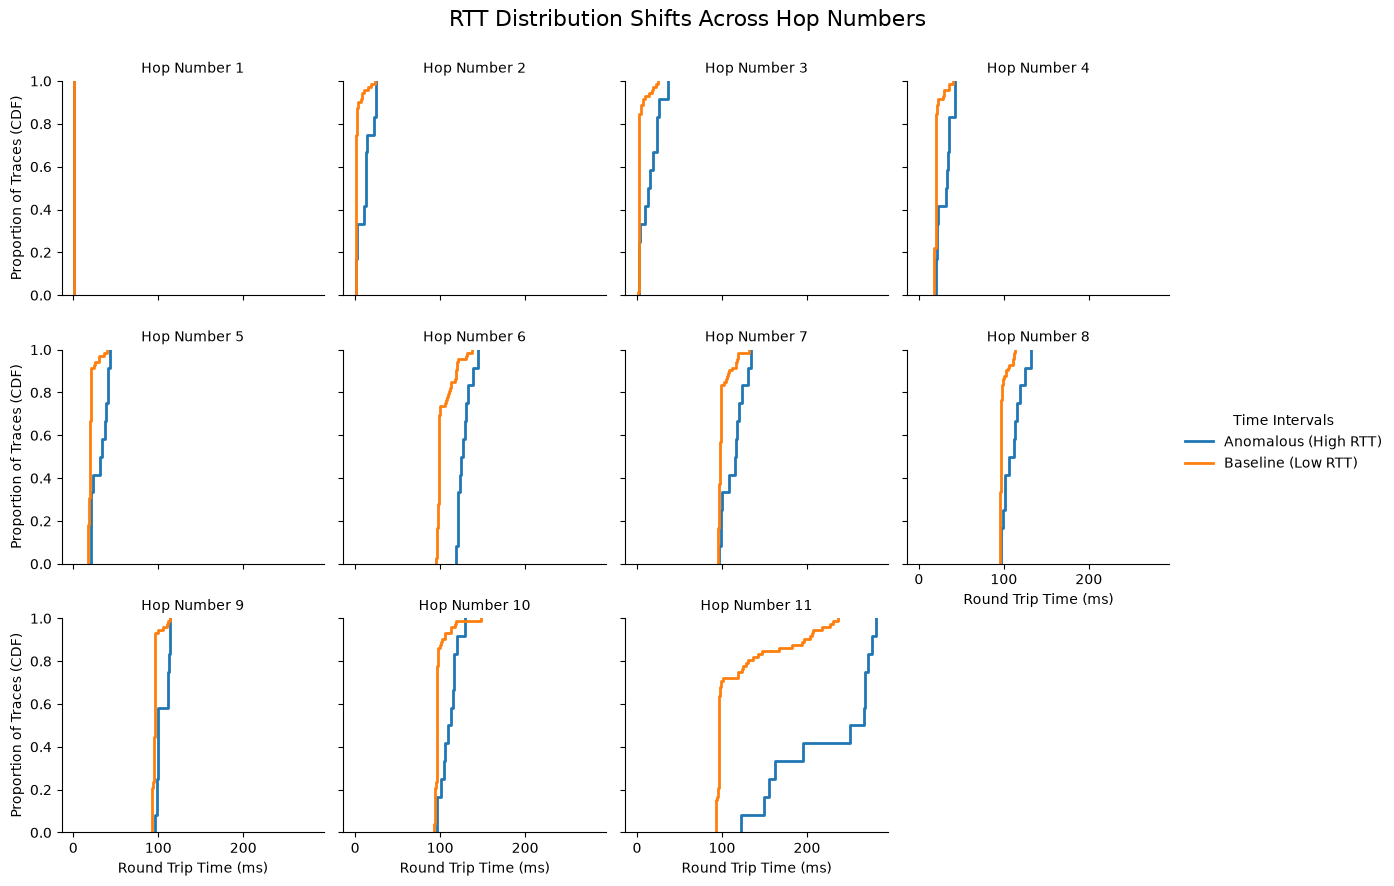

In [199]:
ids_interval_1 = spike1.index
ids_interval_2 = non_spike.index
df_hops['hop_num_rtt'] = pd.to_numeric(df_hops['hop_rtt'], errors='coerce')

hops_int1 = df_hops[df_hops['trace_id'].isin(ids_interval_1)].copy()

hops_int2 = df_hops[df_hops['trace_id'].isin(ids_interval_2)].copy()

hops_int2['Interval'] = 'Baseline (Low RTT)'
hops_int1['Interval'] = 'Anomalous (High RTT)'

df_analysis = pd.concat([hops_int1, hops_int2], ignore_index=True)
df_plot = df_analysis.dropna(subset=['hop_num_rtt']).copy()

g = sns.FacetGrid(df_plot, col="hop_number", hue="Interval", 
                  col_wrap=4, height=3, sharex=True, sharey=True)

# Map an empirical CDF plot onto each facet
g.map(sns.ecdfplot, "hop_num_rtt", linewidth=2)

# Styling adjustments
g.add_legend(title="Time Intervals")
g.set_axis_labels("Round Trip Time (ms)", "Proportion of Traces (CDF)")
g.set_titles("Hop Number {col_name}")

plt.subplots_adjust(top=0.9)
g.fig.suptitle("RTT Distribution Shifts Across Hop Numbers", fontsize=16)

plt.show()

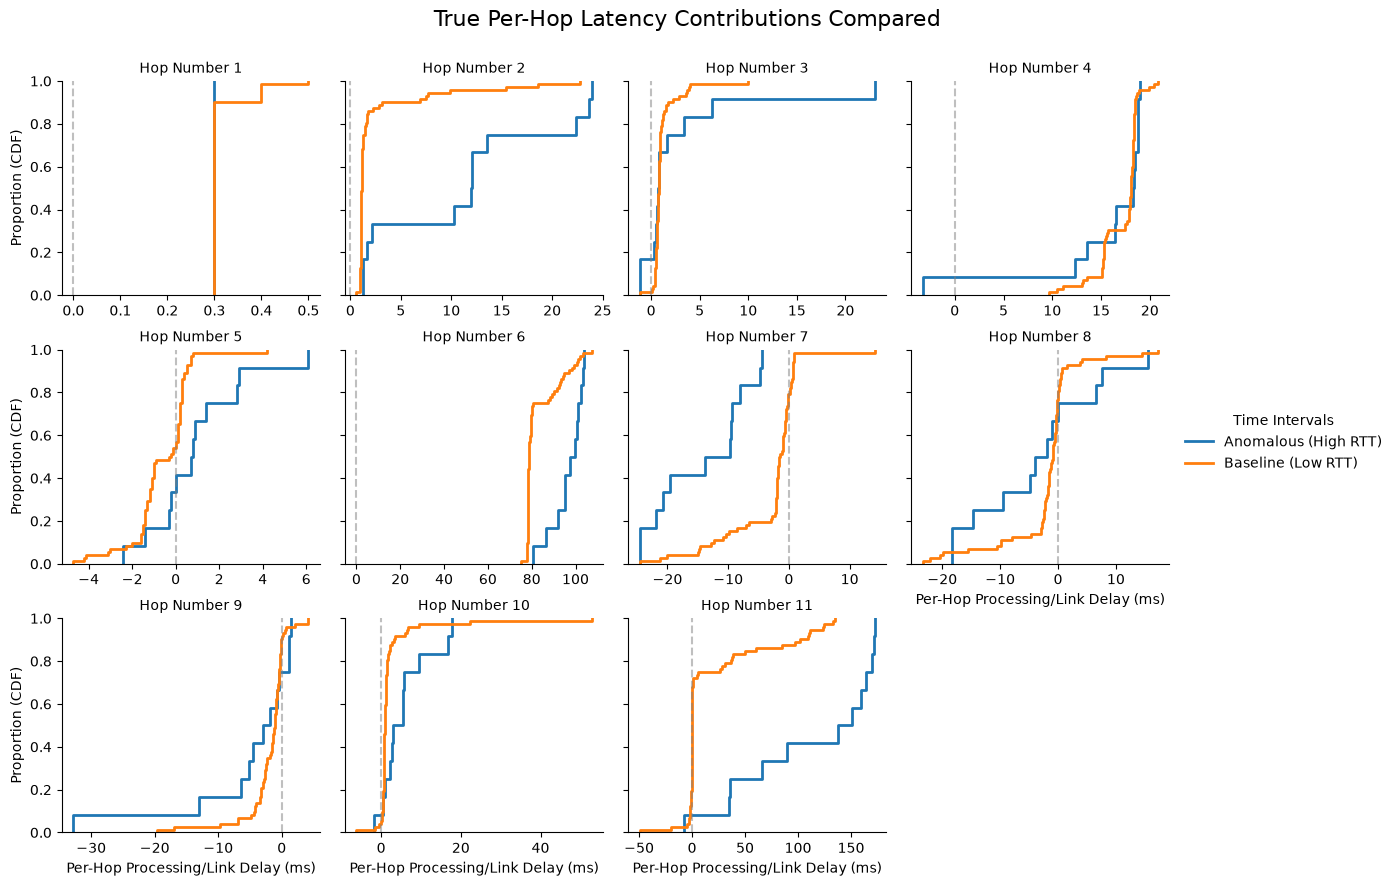

In [200]:
# 1. Clean the column to float numbers (converting '*' to NaN)
# df_hops['hop_rtt'] = pd.to_numeric(df_hops['hop_rtt'], errors='coerce')

# 2. Crucial: Sort by trace and hop sequence so the math aligns perfectly
df_hops = df_hops.sort_values(by=['trace_id', 'hop_number'])

# 3. Compute the incremental delay (Hop N RTT - Hop N-1 RTT)
df_hops['per_hop_contribution'] = df_hops.groupby('trace_id')['hop_num_rtt'].diff()

# 4. Handle Hop 1: Since Hop 1 has no previous hop, .diff() leaves it as NaN.
# But Hop 1's cumulative RTT *is* its per-hop contribution!
hop_1_mask = df_hops['hop_number'] == 1
df_hops.loc[hop_1_mask, 'per_hop_contribution'] = pd.to_numeric(
    df_hops.loc[hop_1_mask, 'hop_rtt'], errors='coerce'
)

ids_interval_1 = spike1.index
ids_interval_2 = non_spike.index

# Extract segments
hops_int1 = df_hops[df_hops['trace_id'].isin(ids_interval_1)].copy()
hops_int2 = df_hops[df_hops['trace_id'].isin(ids_interval_2)].copy()

# Label intervals
hops_int2['Interval'] = 'Baseline (Low RTT)'
hops_int1['Interval'] = 'Anomalous (High RTT)'

# Combine and drop NaNs (which include drops and missing structural elements)
df_analysis = pd.concat([hops_int1, hops_int2], ignore_index=True)
df_plot = df_analysis.dropna(subset=['per_hop_contribution']).copy()

g = sns.FacetGrid(df_plot, col="hop_number", hue="Interval", 
                  col_wrap=4, height=3, sharex=False, sharey=True)

# Map the Empirical CDF using the per-hop column
g.map(sns.ecdfplot, "per_hop_contribution", linewidth=2)

# Styling adjustments
g.add_legend(title="Time Intervals")
g.set_axis_labels("Per-Hop Processing/Link Delay (ms)", "Proportion (CDF)")
g.set_titles("Hop Number {col_name}")

# Set a reasonable x-axis limit if negative/positive outliers stretch the graph
for ax in g.axes.flatten():
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5) # Mark 0ms reference

plt.subplots_adjust(top=0.9)
g.fig.suptitle("True Per-Hop Latency Contributions Compared", fontsize=16)

plt.show()

In [201]:
spike1

,site_id,year,month,day,time,timezone,probe_id,dest,is_timeout,max_hops
trace_id,,,,,,,,,,
12909,10,2026,6,14,15:01:19,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12918,10,2026,6,14,15:16:27,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12925,10,2026,6,14,15:31:23,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12933,10,2026,6,14,15:46:20,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12941,10,2026,6,14,16:01:24,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12950,10,2026,6,14,16:16:29,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12957,10,2026,6,14,16:31:24,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12966,10,2026,6,14,16:46:30,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11
12974,10,2026,6,14,17:01:32,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I...",False,11


Total traces: 192
          day      time
trace_id               
12889      14  14:28:07
12897      14  14:43:09
12905      14  14:58:04
12912      14  15:13:06
12920      14  15:27:55
12929      14  15:43:09
12937      14  15:58:03
12944      14  16:13:00
12952      14  16:28:07
12961      14  16:43:08

Before traces: 39
After traces: 56


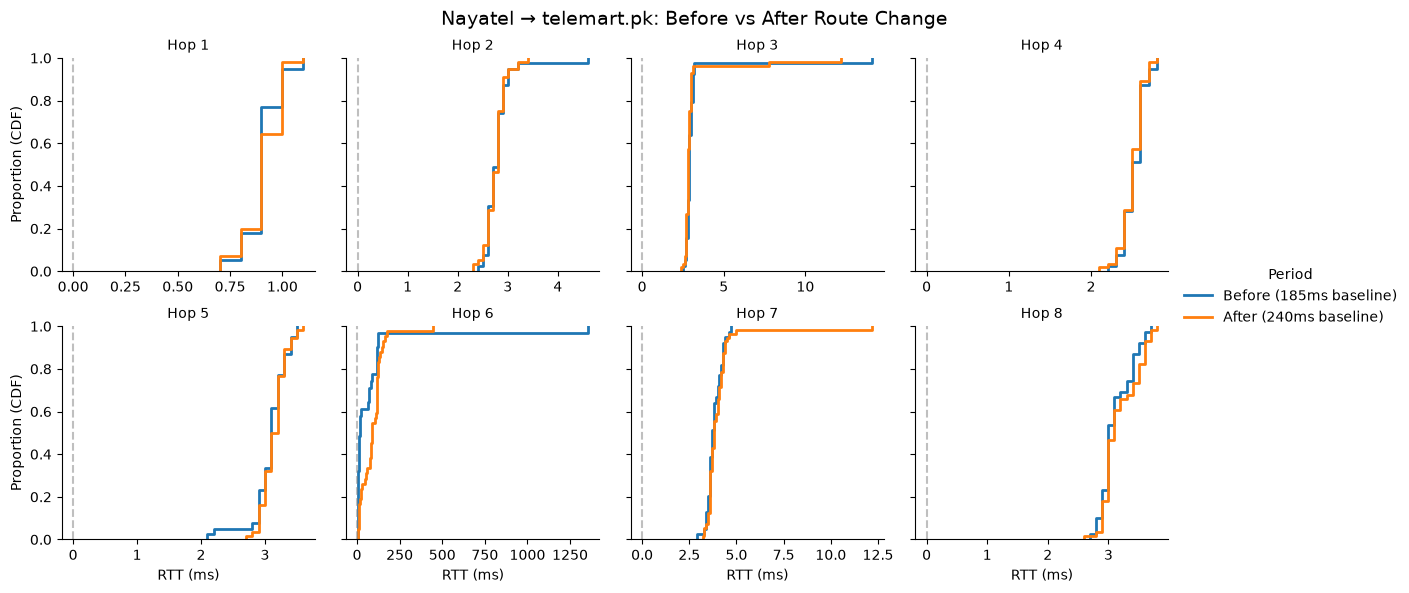

In [202]:
# ── Nayatel → telemart.pk anomaly investigation ───────────────────────────────

# get site_id for telemart.pk
telemart_id = sites[sites['target_hostname'] == 'telemart.pk'].index[0]
nayatel_id = 60223

# filter to this probe-site pair
mask = (
    (df_complete_traces_true_hops['site_id'] == telemart_id) &
    (df_complete_traces_true_hops['probe_id'] == nayatel_id)
)
nayatel_telemart = df_complete_traces_true_hops[mask].copy()

print(f"Total traces: {len(nayatel_telemart)}")
print(nayatel_telemart[['day','time']].head(10))

# split into before and after the step change (June 15 ~08:00)
before = nayatel_telemart[
    (nayatel_telemart['day'] == 14)
]

after = nayatel_telemart[
    (nayatel_telemart['day'] == 15) &
    (nayatel_telemart['time'] >= '10:00:00')
]

print(f"\nBefore traces: {len(before)}")
print(f"After traces: {len(after)}")

# get hops for each period
hops_before = df_hops[df_hops['trace_id'].isin(before.index)].copy()
hops_after  = df_hops[df_hops['trace_id'].isin(after.index)].copy()

hops_before['Interval'] = 'Before (185ms baseline)'
hops_after['Interval']  = 'After (240ms baseline)'

df_analysis = pd.concat([hops_before, hops_after], ignore_index=True)
df_plot = df_analysis.dropna(subset=['hop_num_rtt']).copy()

# CDF facet plot per hop
g = sns.FacetGrid(df_plot, col='hop_number', hue='Interval',
                  col_wrap=4, height=3, sharex=False, sharey=True)
g.map(sns.ecdfplot, 'hop_num_rtt', linewidth=2)
g.add_legend(title='Period')
g.set_axis_labels('RTT (ms)', 'Proportion (CDF)')
g.set_titles('Hop {col_name}')
for ax in g.axes.flatten():
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Nayatel → telemart.pk: Before vs After Route Change', fontsize=14)
plt.show()

In [203]:
summary = (
    df_plot.groupby(['hop_number', 'Interval'])['hop_num_rtt']
    .agg(n='count', mean='mean', median='median',
         p90=lambda x: x.quantile(0.90),
         p99=lambda x: x.quantile(0.99),
         max='max')
    .round(1)
    .reset_index()
    .sort_values(['hop_number', 'Interval'])
)

print(summary.to_string(index=False))

 hop_number                Interval  n  mean  median   p90   p99    max
          1  After (240ms baseline) 56   0.9     0.9   1.0   1.0    1.1
          1 Before (185ms baseline) 39   0.9     0.9   1.0   1.1    1.1
          2  After (240ms baseline) 56   2.8     2.8   2.9   3.3    3.4
          2 Before (185ms baseline) 39   2.8     2.8   3.0   4.1    4.6
          3  After (240ms baseline) 56   3.1     2.8   3.0   9.8   12.2
          3 Before (185ms baseline) 39   3.2     2.9   3.1  10.0   14.1
          4  After (240ms baseline) 56   2.5     2.5   2.7   2.7    2.8
          4 Before (185ms baseline) 39   2.5     2.5   2.7   2.8    2.8
          5  After (240ms baseline) 56   3.1     3.2   3.4   3.5    3.6
          5 Before (185ms baseline) 39   3.1     3.1   3.4   3.5    3.5
          6  After (240ms baseline) 42  91.6    89.2 144.5 335.0  446.1
          6 Before (185ms baseline) 31  84.6    15.3 118.9 984.4 1354.2
          7  After (240ms baseline) 56   4.0     3.8   4.4   8.2

In [205]:
# Wide table: one row per trace (with timestamp), one column per hop, tagged with period
df_plot_indexed = df_analysis.dropna(subset=['hop_num_rtt']).copy()
df_plot_indexed = df_plot_indexed.reset_index()  # no drop=True, turns index into a column
# pull timestamp info back in from the trace table
trace_meta = nayatel_telemart[['day', 'time']].reset_index()
trace_meta = trace_meta.rename(columns={'index': 'trace_id'})  # only if needed, see below

df_plot_indexed = df_plot_indexed.merge(trace_meta, on='trace_id', how='left')

# pivot: rows = trace (day/time/Interval), columns = hop_number, values = RTT
table = df_plot_indexed.pivot_table(
    index=['day', 'time', 'Interval'],
    columns='hop_number',
    values='hop_num_rtt'
).reset_index()

table.columns.name = None
table = table.rename(columns={c: f'hop_{c}' for c in table.columns if isinstance(c, (int, float))})

table = table.sort_values(['Interval', 'day', 'time'])
print(table.to_string(index=False))

 day     time                Interval  hop_1  hop_2  hop_3  hop_4  hop_5  hop_6  hop_7  hop_8
  15 10:13:05  After (240ms baseline)    0.9    2.8    2.8    2.4    2.9    NaN    4.1    3.7
  15 10:27:56  After (240ms baseline)    0.9    2.9    2.7    2.6    3.3    NaN    4.0    3.6
  15 10:42:58  After (240ms baseline)    0.9    2.9    3.0    2.4    3.3  175.2    4.2    3.6
  15 10:57:57  After (240ms baseline)    1.0    3.0    2.9    2.3    3.2   81.9    4.1    3.4
  15 11:12:58  After (240ms baseline)    0.9    2.7    2.8    2.6    3.1  118.1    3.9    3.3
  15 11:28:04  After (240ms baseline)    0.9    2.8    2.5    2.5    3.1  120.5    3.6    2.9
  15 11:43:05  After (240ms baseline)    0.9    2.8    2.9    2.5    3.2   83.6    3.8    3.0
  15 11:58:04  After (240ms baseline)    1.1    2.8    2.9    2.5    3.2  119.4    3.6    3.0
  15 12:12:55  After (240ms baseline)    0.9    2.6    2.9    2.5    3.1  152.9    3.7    3.0
  15 12:28:07  After (240ms baseline)    1.0    3.0    2.8  

In [206]:
table.to_csv('nayatel_telemart_hop_timeseries.csv', index=False)

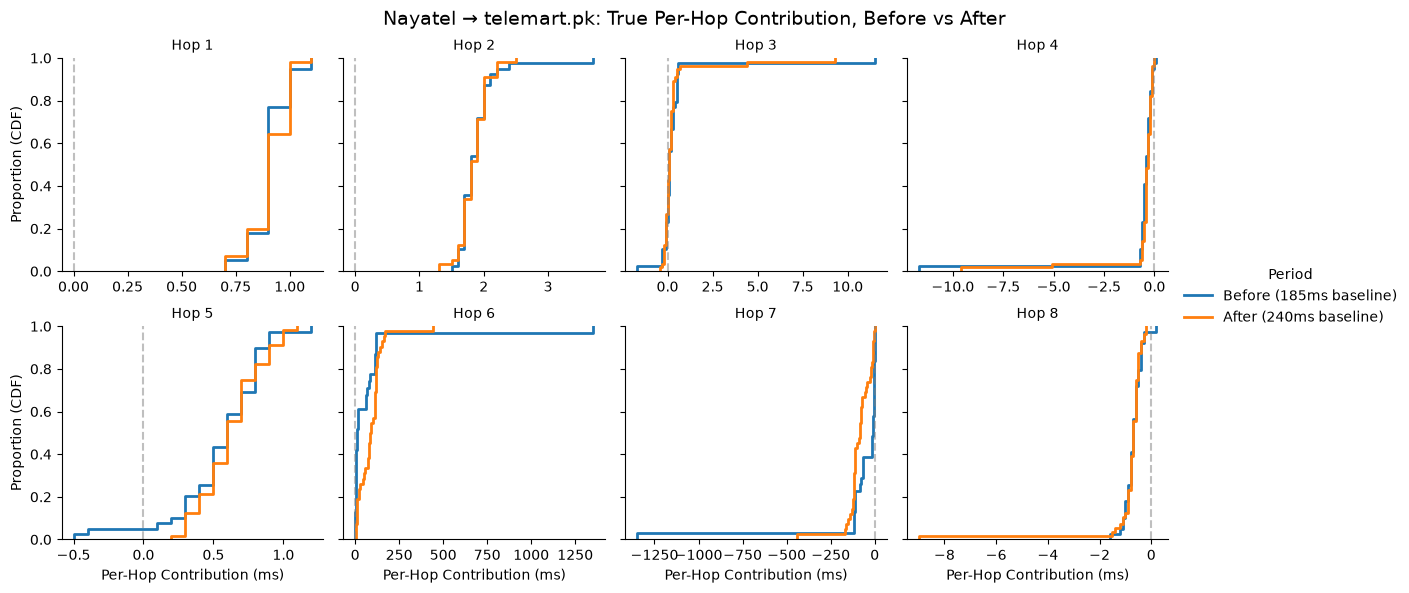

Traces with negative hop-7 contribution (impossible if real): 60 / 95
 trace_id                Interval  hop_num_rtt_6  hop_num_rtt_7  per_hop_contribution_6  per_hop_contribution_7  artifact_flag
    12889 Before (185ms baseline)          118.2            3.6                   114.7                  -114.6           True
    12897 Before (185ms baseline)          117.3            3.8                   115.2                  -113.5           True
    12905 Before (185ms baseline)           12.5            3.8                     9.3                    -8.7           True
    12912 Before (185ms baseline)           15.3            3.7                    12.0                   -11.6           True
    12929 Before (185ms baseline)           82.2            4.1                    79.3                   -78.1           True
    12937 Before (185ms baseline)          118.3            3.8                   115.2                  -114.5           True
    12952 Before (185ms baseline)        

In [207]:
# ── Nayatel → telemart.pk: true per-hop (link-delay) analysis ────────────────

# 1. Sort so the diff aligns correctly within each trace
df_hops = df_hops.sort_values(by=['trace_id', 'hop_number'])

# 2. Compute per-hop contribution (Hop N RTT - Hop N-1 RTT)
df_hops['per_hop_contribution'] = df_hops.groupby('trace_id')['hop_num_rtt'].diff()

# 3. Hop 1 has no previous hop — its contribution is just its own RTT
hop_1_mask = df_hops['hop_number'] == 1
df_hops.loc[hop_1_mask, 'per_hop_contribution'] = df_hops.loc[hop_1_mask, 'hop_num_rtt']

# 4. Re-extract hops for the Nayatel before/after trace_ids (now with the new column)
hops_before = df_hops[df_hops['trace_id'].isin(before.index)].copy()
hops_after  = df_hops[df_hops['trace_id'].isin(after.index)].copy()

hops_before['Interval'] = 'Before (185ms baseline)'
hops_after['Interval']  = 'After (240ms baseline)'

df_analysis = pd.concat([hops_before, hops_after], ignore_index=True)
df_plot = df_analysis.dropna(subset=['per_hop_contribution']).copy()

# 5. CDF facet plot using the true per-hop contribution
g = sns.FacetGrid(df_plot, col='hop_number', hue='Interval',
                  col_wrap=4, height=3, sharex=False, sharey=True)
g.map(sns.ecdfplot, 'per_hop_contribution', linewidth=2)
g.add_legend(title='Period')
g.set_axis_labels('Per-Hop Contribution (ms)', 'Proportion (CDF)')
g.set_titles('Hop {col_name}')
for ax in g.axes.flatten():
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Nayatel → telemart.pk: True Per-Hop Contribution, Before vs After', fontsize=14)
plt.show()

# 6. Diagnostic table: flag the impossible-negative-delay artifact at hop 7
diagnostic = df_analysis[df_analysis['hop_number'].isin([6, 7])].pivot_table(
    index=['trace_id', 'Interval'],
    columns='hop_number',
    values=['hop_num_rtt', 'per_hop_contribution']
)
diagnostic.columns = ['_'.join(map(str, c)) for c in diagnostic.columns]
diagnostic = diagnostic.reset_index()
diagnostic['artifact_flag'] = diagnostic['per_hop_contribution_7'] < -5

print(f"Traces with negative hop-7 contribution (impossible if real): "
      f"{diagnostic['artifact_flag'].sum()} / {len(diagnostic)}")
print(diagnostic[diagnostic['artifact_flag']].to_string(index=False))

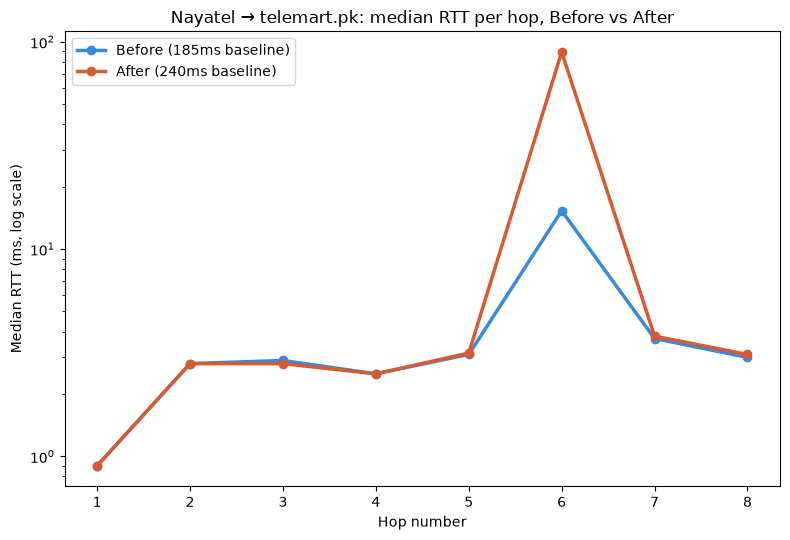

In [221]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('nayatel_telemart_hop_timeseries.csv')
hop_cols = [f'hop_{i}' for i in range(1, 9)]
hop_nums = list(range(1, 9))

before = df[df['Interval'].str.contains('Before')]
after  = df[df['Interval'].str.contains('After')]

before_median = before[hop_cols].median()
after_median  = after[hop_cols].median()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(hop_nums, before_median.values, marker='o', color='#378ADD', linewidth=2.5, label='Before (185ms baseline)')
ax.plot(hop_nums, after_median.values,  marker='o', color='#D85A30', linewidth=2.5, label='After (240ms baseline)')

ax.set_yscale('log')
ax.set_xlabel('Hop number')
ax.set_ylabel('Median RTT (ms, log scale)')
ax.set_xticks(hop_nums)
ax.set_title('Nayatel → telemart.pk: median RTT per hop, Before vs After')
ax.legend()

plt.tight_layout()
plt.savefig('nayatel_median_before_after.png', dpi=150)
plt.show()

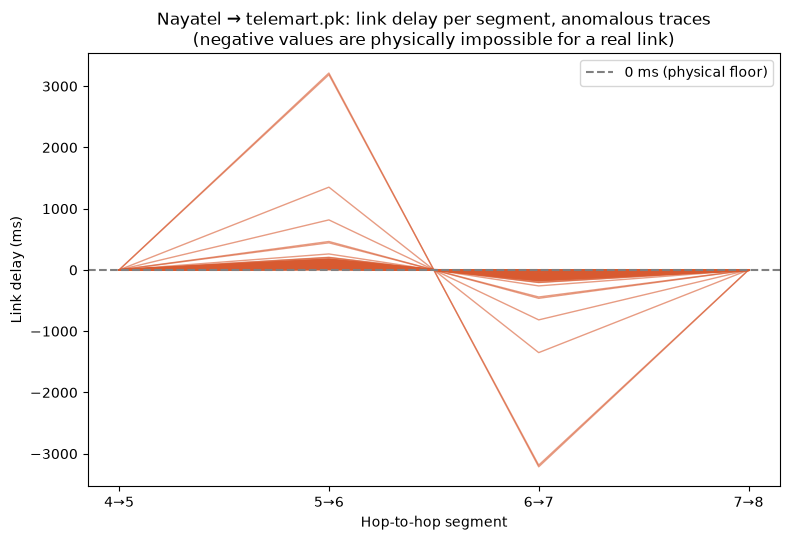

In [223]:
import matplotlib.pyplot as plt

# get anomalous traces (adjust threshold as needed)
anomalous_ids = nayatel_telemart[nayatel_telemart.index.isin(
    df_hops[(df_hops['hop_number'] == 6) & (df_hops['hop_num_rtt'] > 10)]['trace_id']
)].index

hops_anom = df_hops[df_hops['trace_id'].isin(anomalous_ids)].copy()

fig, ax = plt.subplots(figsize=(8, 5.5))

for trace_id, group in hops_anom.groupby('trace_id'):
    group = group.sort_values('hop_number')
    seg = group[group['hop_number'].isin([4,5,6,7,8])]
    ax.plot(['4→5','5→6','6→7','7→8'],
             seg['per_hop_contribution'].values[1:],  # skip hop 4's own value, plot segments
             color='#D85A30', linewidth=1, alpha=0.6)

ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='0 ms (physical floor)')
ax.set_xlabel('Hop-to-hop segment')
ax.set_ylabel('Link delay (ms)')
ax.set_title('Nayatel → telemart.pk: link delay per segment, anomalous traces\n(negative values are physically impossible for a real link)')
ax.legend()

plt.tight_layout()
plt.show()

## Nayatel → telemart.pk: Hop-Level RTT Anomaly Analysis

### Setup
Traces were split into two periods around the observed step change in overall RTT (185ms baseline before June 15, 240ms baseline after):

- **Before**: all traces from day 14
- **After**: traces from day 15, starting 10:00 (to exclude the transition window itself)

Per-hop RTT (`hop_num_rtt`) was compared across periods using empirical CDFs, one panel per hop.

### Hop-by-hop findings

**Hops 1, 2, 3, 4, 5, 7, 8**: distributions are nearly identical before and after. No hop shows a shift consistent with the ~55ms baseline increase. This rules out a simple, uniform "longer path" explanation for the overall RTT jump.

**Hop 6**: the clear outlier. RTT values here range from single digits up to over 1300ms, dwarfing every other hop (which stay under 15ms in all cases). The distribution shape also differs between periods: Before shows a longer, thinner tail extending to ~1350ms; After shows a shorter, denser plateau around ~450-500ms. Additionally, hop 6 fails to respond entirely in roughly 21% of Before traces and 25% of After traces.

- **Anomaly**: Hop 6 in the Nayatel → telemart.pk path shows intermittent, extreme RTT spikes (up to 1354ms), while all other hops stay flat (1-6ms) in both periods.

- **Not a real routing/congestion issue**: Hop 6's spikes don't propagate downstream — hop 7 and hop 8 return to normal RTT immediately after, even when hop 6 spikes to 1000+ ms.

- **Proof via link delay**: Computing link delay (`hop_n - hop_{n-1}`) shows hop 7's segment going strongly negative (e.g. -1349.9ms) exactly mirroring hop 6's spike (+1351.4ms). Negative link delay is physically impossible for a real network segment, confirming hop 6's RTT inflation is a local artifact, not real path congestion.

- **Likely cause**: Router 6 appears to deprioritize/rate-limit its own ICMP reply generation (a known, common traceroute artifact) rather than experiencing genuine forwarding delay.

- **Before vs After (the actual baseline shift, June 14 → June 15)**:
  - Individual spike magnitude did not increase — max spike was actually *larger* Before (1354ms) than After (446ms)
  - What changed is *frequency*: hop 6 misbehaved in 58% of Before traces (18/31) vs 95% of After traces (40/42)
  - This frequency increase, not spike size, is the more likely driver of the aggregate RTT baseline moving from 185ms to 240ms

- **Recommendation**: Exclude hop 6 from per-hop delay analysis; use a combined delay across hops 5→7 (bypassing hop 6's unreliable reading) to test for genuine path changes. Also worth checking hop 8 (or destination) RTT in isolation to confirm the 185→240ms step is real and independent of hop 6 noise.

Nova→dawn baseline traces: 11, spike traces: 28


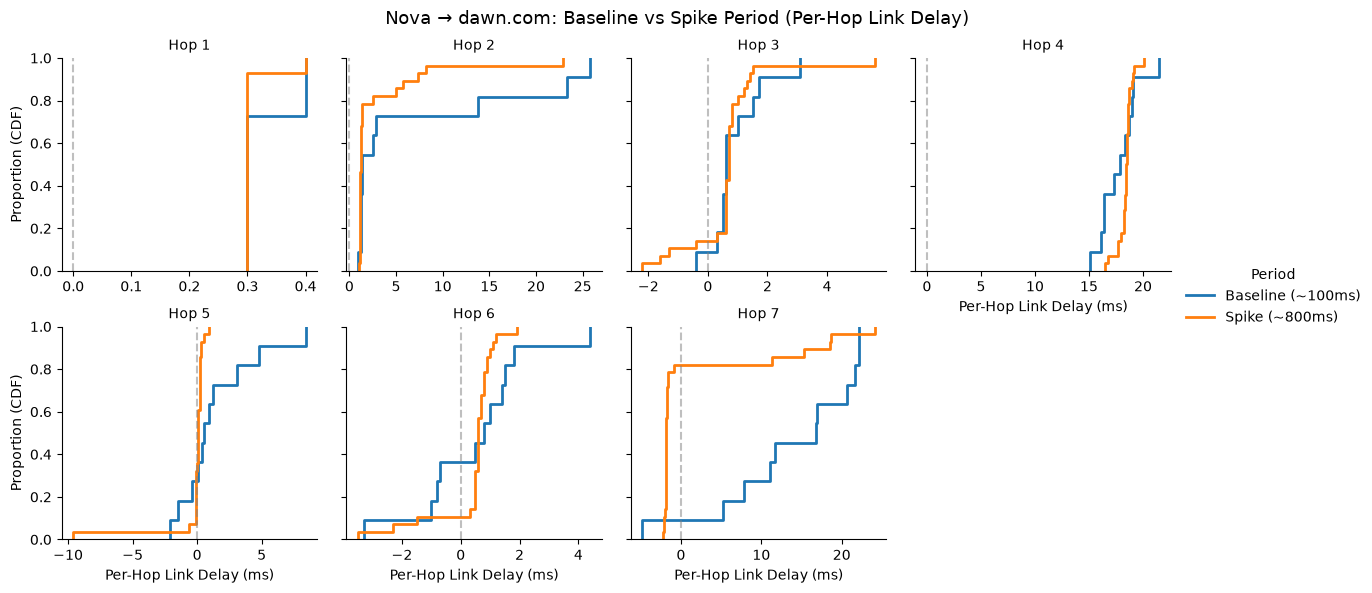

In [216]:
# ── ANOMALY 1: Nova → dawn.com ────────────────────────────────────────────────

dawn_id   = sites[sites['target_hostname'] == 'dawn.com'].index[0]
nova_id   = 1015679

mask = (
    (df_complete_traces_true_hops['site_id'] == dawn_id) &
    (df_complete_traces_true_hops['probe_id'] == nova_id)
)
nova_dawn = df_complete_traces_true_hops[mask].copy()

# baseline: June 14 14:00-16:00 (stable before first spike)
baseline_nd = nova_dawn[
    (nova_dawn['day'] == 14) &
    (nova_dawn['time'] >= '14:00:00') &
    (nova_dawn['time'] <= '17:00:00')
]

# spike: June 14 19:00-20:00 (800ms spike period)
spike_nd = nova_dawn[
    (nova_dawn['day'] == 14) &
    (nova_dawn['time'] >= '19:00:00') 
]

spike_nd2 = nova_dawn[
    (nova_dawn['day'] == 15) &
    (nova_dawn['time'] <= '02:00:00')
]
spike_nd = pd.concat([spike_nd, spike_nd2])

print(f"Nova→dawn baseline traces: {len(baseline_nd)}, spike traces: {len(spike_nd)}")

hops_baseline = df_hops[df_hops['trace_id'].isin(baseline_nd.index)].copy()
hops_spike    = df_hops[df_hops['trace_id'].isin(spike_nd.index)].copy()

hops_baseline['Interval'] = 'Baseline (~100ms)'
hops_spike['Interval']    = 'Spike (~800ms)'

df_plot1 = pd.concat([hops_baseline, hops_spike], ignore_index=True)
df_plot1 = df_plot1.dropna(subset=['per_hop_contribution'])

g1 = sns.FacetGrid(df_plot1, col='hop_number', hue='Interval',
                   col_wrap=4, height=3, sharex=False, sharey=True)
g1.map(sns.ecdfplot, 'per_hop_contribution', linewidth=2)
g1.add_legend(title='Period')
g1.set_axis_labels('Per-Hop Link Delay (ms)', 'Proportion (CDF)')
g1.set_titles('Hop {col_name}')
for ax in g1.axes.flatten():
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Nova → dawn.com: Baseline vs Spike Period (Per-Hop Link Delay)', fontsize=13)
plt.show()





In [209]:
print(nova_dawn['day'].dtype)
print(nova_dawn['day'].unique())
print(nova_dawn['time'].unique()[:5])

int64
[14 15 16]
<StringArray>
['14:26:11', '14:41:10', '14:56:18', '15:11:12', '15:26:06']
Length: 5, dtype: str


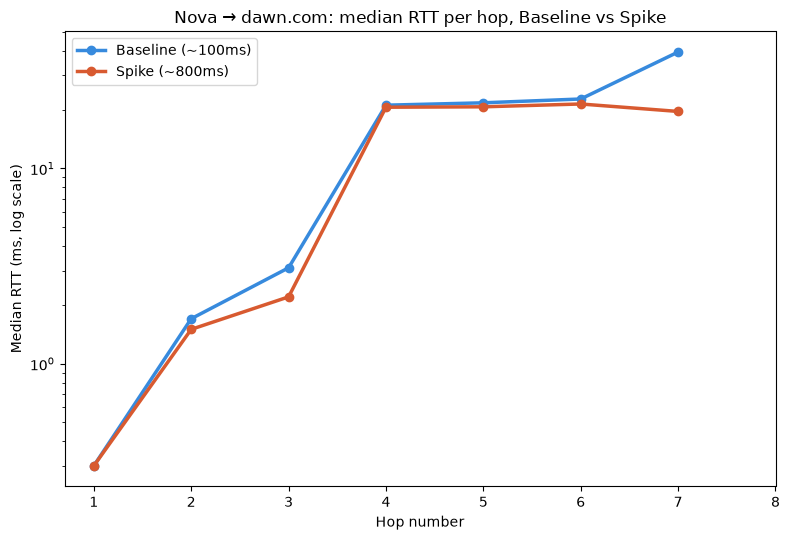

In [222]:
import matplotlib.pyplot as plt

hop_nums = list(range(1, 9))  # adjust if dawn.com path has a different hop count

# get hops for baseline and spike periods
hops_baseline = df_hops[df_hops['trace_id'].isin(baseline_nd.index)].copy()
hops_spike    = df_hops[df_hops['trace_id'].isin(spike_nd.index)].copy()

# median hop_num_rtt per hop, for each period
baseline_median = hops_baseline.groupby('hop_number')['hop_num_rtt'].median().reindex(hop_nums)
spike_median    = hops_spike.groupby('hop_number')['hop_num_rtt'].median().reindex(hop_nums)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(hop_nums, baseline_median.values, marker='o', color='#378ADD', linewidth=2.5, label='Baseline (~100ms)')
ax.plot(hop_nums, spike_median.values,    marker='o', color='#D85A30', linewidth=2.5, label='Spike (~800ms)')

ax.set_yscale('log')
ax.set_xlabel('Hop number')
ax.set_ylabel('Median RTT (ms, log scale)')
ax.set_xticks(hop_nums)
ax.set_title('Nova → dawn.com: median RTT per hop, Baseline vs Spike')
ax.legend()

plt.tight_layout()
plt.show()

Before traces: 39, After traces: 9


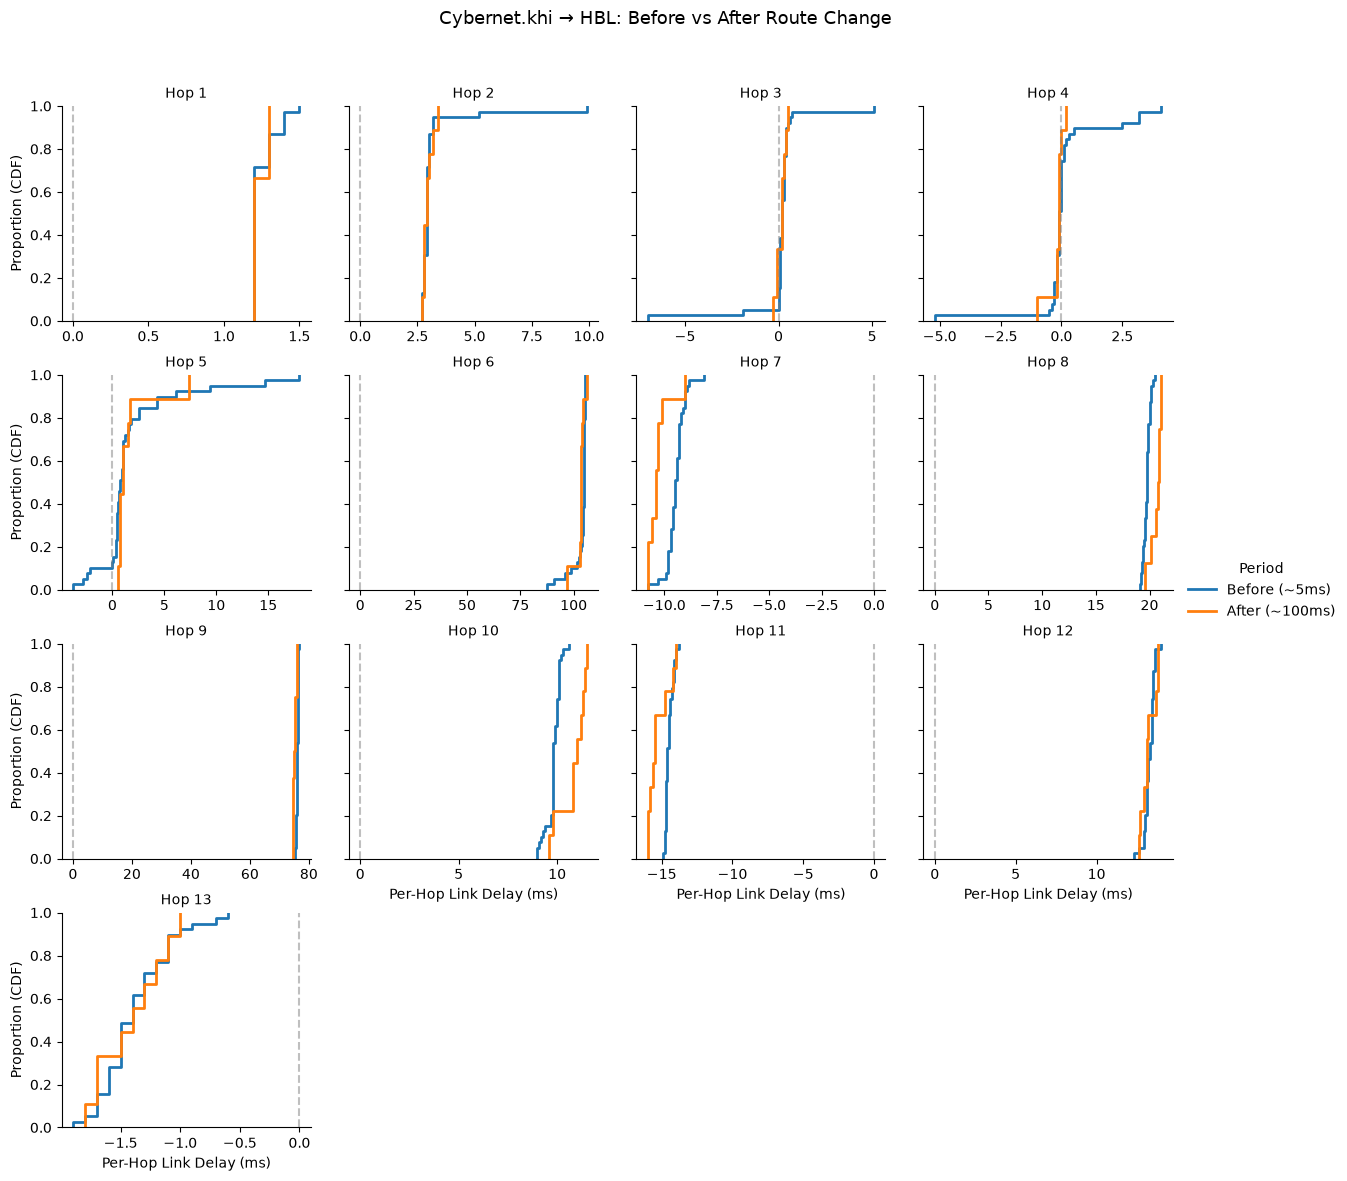

In [214]:
hbl_id       = sites[sites['target_hostname'] == 'hbl.com'].index[0]
cybernet_khi = 1016143

mask2 = (
    (df_complete_traces_true_hops['site_id'] == hbl_id) &
    (df_complete_traces_true_hops['probe_id'] == cybernet_khi)
)
cyber_hbl = df_complete_traces_true_hops[mask2].copy()

before_ch = cyber_hbl[cyber_hbl['day'] == 14]

after_ch = cyber_hbl[
    (cyber_hbl['day'] == 15) &
    (cyber_hbl['time'] >= '10:00:00') &
    (cyber_hbl['time'] <= '18:00:00')
]

print(f"Before traces: {len(before_ch)}, After traces: {len(after_ch)}")

hops_before_ch = df_hops[df_hops['trace_id'].isin(before_ch.index)].copy()
hops_after_ch  = df_hops[df_hops['trace_id'].isin(after_ch.index)].copy()

hops_before_ch['Interval'] = 'Before (~5ms)'
hops_after_ch['Interval']  = 'After (~100ms)'

df_plot2 = pd.concat([hops_before_ch, hops_after_ch], ignore_index=True)
df_plot2 = df_plot2.dropna(subset=['per_hop_contribution'])

g2 = sns.FacetGrid(df_plot2, col='hop_number', hue='Interval',
                   col_wrap=4, height=3, sharex=False, sharey=True)
g2.map(sns.ecdfplot, 'per_hop_contribution', linewidth=2)
g2.add_legend(title='Period')
g2.set_axis_labels('Per-Hop Link Delay (ms)', 'Proportion (CDF)')
g2.set_titles('Hop {col_name}')
for ax in g2.axes.flatten():
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Cybernet.khi → HBL: Before vs After Route Change', fontsize=13)
plt.show()

**Cybernet Karachi → HBL: Routing Anomaly**

On June 15 at approximately 10:00 UTC, Cybernet Karachi (AS9541) experienced a sustained routing change on its path to HBL's hosting provider Incapsula (AS19551) in New Jersey. Prior to this event, the probe consistently reached HBL with a median RTT of approximately 5ms — anomalously low for a US-hosted destination, suggesting a nearby or cached serving point. Following the change, RTT stabilised at approximately 100ms for the remainder of the measurement window before gradually recovering toward the end of the 48-hour period.

Per-hop link delay analysis isolates the cause to a single link at hop 6. In the pre-change period, hop 6 contributed near-zero incremental delay, indicating a fast local or regional handoff. In the post-change period, hop 6 alone introduced approximately 75 to 100ms of additional delay while all other hops remained unchanged. This confirms the routing change occurred at a single upstream handoff point rather than being distributed across the path.

The anomaly is consistent with a BGP route withdrawal or preference change at one of Cybernet's upstream transit providers, which forced traffic onto a longer international path at hop 6. Cybernet owns the PEACE submarine cable and peers at DE-CIX Frankfurt and Equinix Singapore — the pre-change 5ms RTT may reflect traffic being served from a regional Incapsula cache or a nearby PoP that became unavailable after the routing event. The gradual recovery visible in the ping time series toward June 16 suggests the original route or serving location was eventually restored.

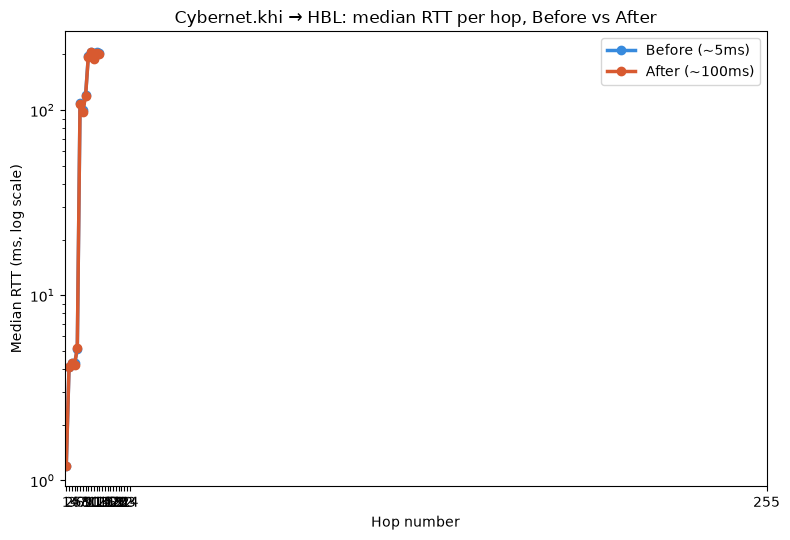

    hop_number  before_median  after_median  jump
4            5            5.1          5.20  0.10
0            1            1.2          1.20  0.00
1            2            4.1          4.10  0.00
2            3            4.3          4.30  0.00
3            4            4.3          4.20 -0.10
9           10          206.0        205.00 -1.00
7            8          120.1        119.05 -1.05
5            6          109.8        108.60 -1.20
11          12          204.8        202.90 -1.90
8            9          196.1        194.10 -2.00
10          11          191.5        189.50 -2.00
12          13          203.4        201.30 -2.10
6            7          100.4         98.10 -2.30
13          14            NaN           NaN   NaN
14          15            NaN           NaN   NaN
15          16            NaN           NaN   NaN
16          17            NaN           NaN   NaN
17          18            NaN           NaN   NaN
18          19            NaN           NaN   NaN


In [224]:
import matplotlib.pyplot as plt

# ── Step 1: Median RTT per hop, Before vs After ───────────────────────────────

hop_nums = sorted(df_hops['hop_number'].dropna().unique().astype(int))

baseline_median_ch = hops_before_ch.groupby('hop_number')['hop_num_rtt'].median().reindex(hop_nums)
spike_median_ch    = hops_after_ch.groupby('hop_number')['hop_num_rtt'].median().reindex(hop_nums)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(hop_nums, baseline_median_ch.values, marker='o', color='#378ADD', linewidth=2.5, label='Before (~5ms)')
ax.plot(hop_nums, spike_median_ch.values,    marker='o', color='#D85A30', linewidth=2.5, label='After (~100ms)')
ax.set_yscale('log')
ax.set_xlabel('Hop number')
ax.set_ylabel('Median RTT (ms, log scale)')
ax.set_xticks(hop_nums)
ax.set_title('Cybernet.khi → HBL: median RTT per hop, Before vs After')
ax.legend()
plt.tight_layout()
plt.show()

# ── Step 2: which hop actually shows the biggest jump? ────────────────────────
diff_table = pd.DataFrame({
    'hop_number': hop_nums,
    'before_median': baseline_median_ch.values,
    'after_median': spike_median_ch.values,
})
diff_table['jump'] = diff_table['after_median'] - diff_table['before_median']
print(diff_table.sort_values('jump', ascending=False))

In [225]:
hop_cols_needed = ['trace_id', 'hop_number', 'hop_num_rtt']

hops_before_wide = df_hops[df_hops['trace_id'].isin(before_ch.index)][hop_cols_needed].copy()
hops_after_wide  = df_hops[df_hops['trace_id'].isin(after_ch.index)][hop_cols_needed].copy()

hops_before_wide['Interval'] = 'Before (~5ms)'
hops_after_wide['Interval']  = 'After (~100ms)'

df_all_ch = pd.concat([hops_before_wide, hops_after_wide], ignore_index=True)

trace_meta_ch = cyber_hbl[['day', 'time']].reset_index()
if 'trace_id' not in trace_meta_ch.columns:
    trace_meta_ch = trace_meta_ch.rename(columns={'index': 'trace_id'})

df_all_ch = df_all_ch.merge(trace_meta_ch, on='trace_id', how='left')

table_ch = df_all_ch.pivot_table(
    index=['trace_id', 'day', 'time', 'Interval'],
    columns='hop_number',
    values='hop_num_rtt'
).reset_index()

table_ch.columns.name = None
table_ch = table_ch.rename(columns={c: f'hop_{c}' for c in table_ch.columns if isinstance(c, (int, float))})
table_ch = table_ch.sort_values(['Interval', 'day', 'time'])

table_ch.to_csv('cybernet_hbl_hop_timeseries.csv', index=False)
print(f"Saved {len(table_ch)} traces")
print(table_ch.head(10))

Saved 48 traces
    trace_id  day      time        Interval  hop_1  hop_2  hop_3  hop_4  \
39      9228   15  10:14:59  After (~100ms)    1.2    3.9    4.3    4.2   
40      9235   15  10:29:47  After (~100ms)    1.2    4.2    3.9    4.1   
41      9243   15  10:44:48  After (~100ms)    1.2    4.6    4.5    4.3   
42      9251   15  10:59:47  After (~100ms)    1.2    4.4    4.3    4.2   
43      9259   15  11:14:58  After (~100ms)    1.2    4.0    4.5    3.5   
44      9267   15  11:29:50  After (~100ms)    1.2    4.1    4.4    4.2   
45      9275   15  11:44:51  After (~100ms)    1.3    4.1    4.3    4.2   
46      9284   15  11:59:49  After (~100ms)    1.3    4.1    4.3    4.3   
47      9291   15  12:14:50  After (~100ms)    1.3    4.2    4.4    4.3   
0       8594   14  14:29:47   Before (~5ms)    1.2    4.1    4.2    7.4   

    hop_5  hop_6  hop_7  hop_8  hop_9  hop_10  hop_11  hop_12  hop_13  
39    4.7  108.3   98.0  119.1  193.6   205.1   189.5   202.6   201.1  
40    5.6  108

In [226]:
print(cyber_hbl[['day','time']].assign(
    total_rtt=cyber_hbl.index.map(
        lambda tid: df_hops[df_hops['trace_id']==tid]['hop_num_rtt'].max()
    )
).to_string(index=False))

 day     time  total_rtt
  14 14:29:47      206.1
  14 14:44:57      206.1
  14 14:59:50      206.3
  14 15:14:58      206.3
  14 15:29:50      206.2
  14 15:44:57      206.4
  14 16:00:00      206.0
  14 16:14:59      205.9
  14 16:30:01      206.2
  14 16:45:00      206.0
  14 17:00:01      206.1
  14 17:14:55      205.9
  14 17:29:50      205.9
  14 17:44:57      205.8
  14 17:59:49      206.3
  14 18:14:51      206.1
  14 18:29:52      205.8
  14 18:44:48      206.0
  14 18:59:47      206.1
  14 19:14:57      206.3
  14 19:29:55      206.2
  14 19:44:50      206.0
  14 20:00:00      206.0
  14 20:14:58      206.2
  14 20:29:54      205.8
  14 20:45:00      206.1
  14 20:59:54      206.2
  14 21:14:58      206.0
  14 21:29:54      206.2
  14 21:44:49      206.0
  14 22:00:01      205.9
  14 22:14:52      205.1
  14 22:29:55      205.8
  14 22:44:56      205.9
  14 22:59:54      205.9
  14 23:14:57      206.0
  14 23:30:00      206.0
  14 23:44:54      205.8
  14 23:59:49      206.0


In [227]:
# full 48-hour RTT time series, no Before/After filtering
cyber_hbl_full = cyber_hbl.copy()
cyber_hbl_full['total_rtt'] = cyber_hbl_full.index.map(
    lambda tid: df_hops[df_hops['trace_id'] == tid]['hop_num_rtt'].max()
)

print(cyber_hbl_full[['day','time','total_rtt']].sort_values(['day','time']).to_string(index=False))

 day     time  total_rtt
  14 14:29:47      206.1
  14 14:44:57      206.1
  14 14:59:50      206.3
  14 15:14:58      206.3
  14 15:29:50      206.2
  14 15:44:57      206.4
  14 16:00:00      206.0
  14 16:14:59      205.9
  14 16:30:01      206.2
  14 16:45:00      206.0
  14 17:00:01      206.1
  14 17:14:55      205.9
  14 17:29:50      205.9
  14 17:44:57      205.8
  14 17:59:49      206.3
  14 18:14:51      206.1
  14 18:29:52      205.8
  14 18:44:48      206.0
  14 18:59:47      206.1
  14 19:14:57      206.3
  14 19:29:55      206.2
  14 19:44:50      206.0
  14 20:00:00      206.0
  14 20:14:58      206.2
  14 20:29:54      205.8
  14 20:45:00      206.1
  14 20:59:54      206.2
  14 21:14:58      206.0
  14 21:29:54      206.2
  14 21:44:49      206.0
  14 22:00:01      205.9
  14 22:14:52      205.1
  14 22:29:55      205.8
  14 22:44:56      205.9
  14 22:59:54      205.9
  14 23:14:57      206.0
  14 23:30:00      206.0
  14 23:44:54      205.8
  14 23:59:49      206.0


In [ ]:
import matplotlib.ticker as mticker

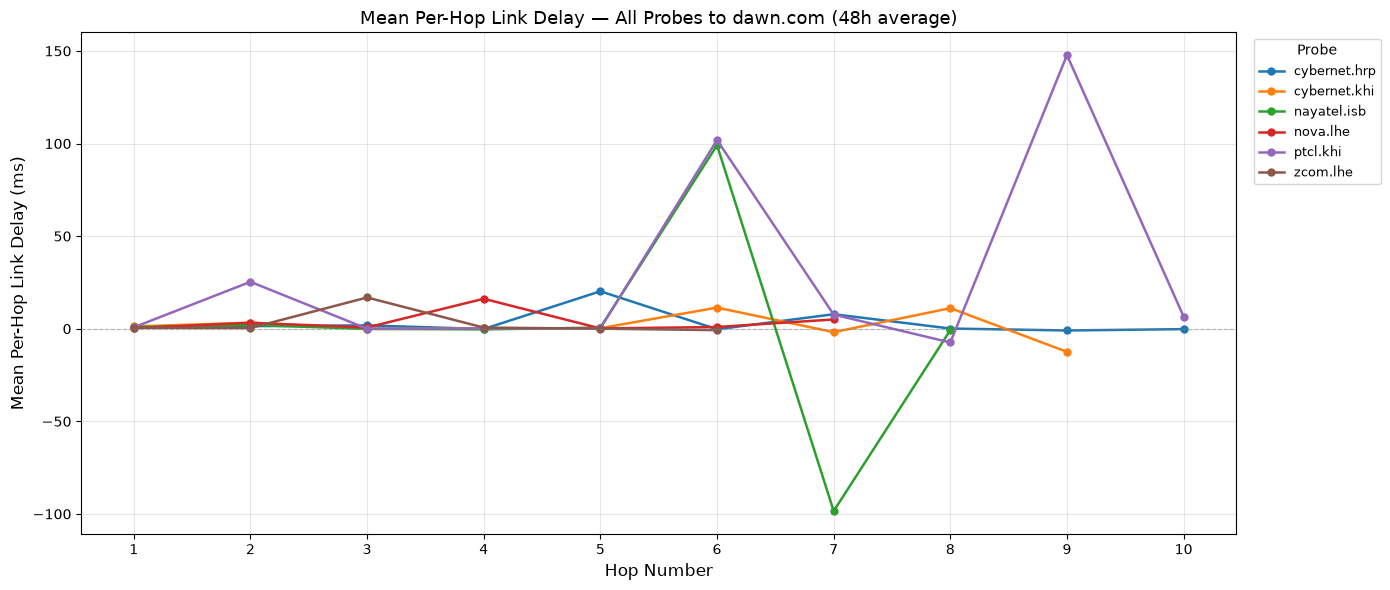


Site: dawn.com (site_id=2)
Probes present: ['cybernet.hrp', 'cybernet.khi', 'nayatel.isb', 'nova.lhe', 'ptcl.khi', 'zcom.lhe']
Total hop rows used: 8235


In [ ]:

# # ── CONFIG ────────────────────────────────────────────────────────────────────
# TARGET_SITE = 'dawn.com'   # change to any site in your dataset
# MAX_HOP     = 20            # only show up to this hop (cuts off rare long tails)
# MIN_SAMPLES = 5             # minimum number of rounds needed to include a hop

# # ── PREP ──────────────────────────────────────────────────────────────────────

# # get site_id for the target
# site_id = sites[sites['target_hostname'] == TARGET_SITE].index[0]

# # get all completed trace_ids for this site
# site_trace_ids = df_complete_traces_true_hops[
#     df_complete_traces_true_hops['site_id'] == site_id
# ].index

# # filter hops to just those traces
# site_hops = df_hops[df_hops['trace_id'].isin(site_trace_ids)].copy()

# # merge probe_id onto hops via trace metadata
# site_hops = site_hops.merge(
#     df_traces[['probe_id']],
#     left_on='trace_id',
#     right_index=True,
#     how='left'
# )

# # add probe label
# probe_label_map = (probes['isp'] + '.' + probes['city_code']).to_dict()
# site_hops['probe_name'] = site_hops['probe_id'].map(probe_label_map)

# # filter to reasonable hop range
# site_hops = site_hops[site_hops['hop_number'] <= MAX_HOP]

# # drop timeouts (no RTT)
# site_hops = site_hops.dropna(subset=['per_hop_contribution'])

# # ── COMPUTE MEAN PER-HOP CONTRIBUTION PER PROBE ───────────────────────────────
# mean_per_hop = (
#     site_hops
#     .groupby(['probe_name', 'hop_number'])['per_hop_contribution']
#     .agg(['mean', 'count'])
#     .reset_index()
# )

# # only keep hop positions with enough samples
# mean_per_hop = mean_per_hop[mean_per_hop['count'] >= MIN_SAMPLES]
# mean_per_hop['mean'] = mean_per_hop['mean'].clip(lower=0)

# # ── PLOT ──────────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(14, 6))

# probes_in_data = mean_per_hop['probe_name'].unique()

# # color palette
# colors = plt.cm.tab10.colors

# for i, probe in enumerate(sorted(probes_in_data)):
#     data = mean_per_hop[mean_per_hop['probe_name'] == probe].sort_values('hop_number')
#     ax.plot(
#         data['hop_number'],
#         data['mean'],
#         marker='o',
#         markersize=5,
#         linewidth=1.8,
#         label=probe,
#         color=colors[i % len(colors)]
#     )

# ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
# ax.set_xlabel('Hop Number', fontsize=12)
# ax.set_ylabel('Mean Per-Hop Link Delay (ms)', fontsize=12)
# ax.set_title(f'Mean Per-Hop Link Delay — All Probes to {TARGET_SITE} (48h average)', fontsize=13)
# ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# ax.legend(title='Probe', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"\nSite: {TARGET_SITE} (site_id={site_id})")
# print(f"Probes present: {sorted(probes_in_data)}")
# print(f"Total hop rows used: {len(site_hops)}")

/var/folders/m9/5jmjjc_s0nb5lcsytjxn98xc0000gn/T/ipykernel_25449/44870672.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Probe', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)


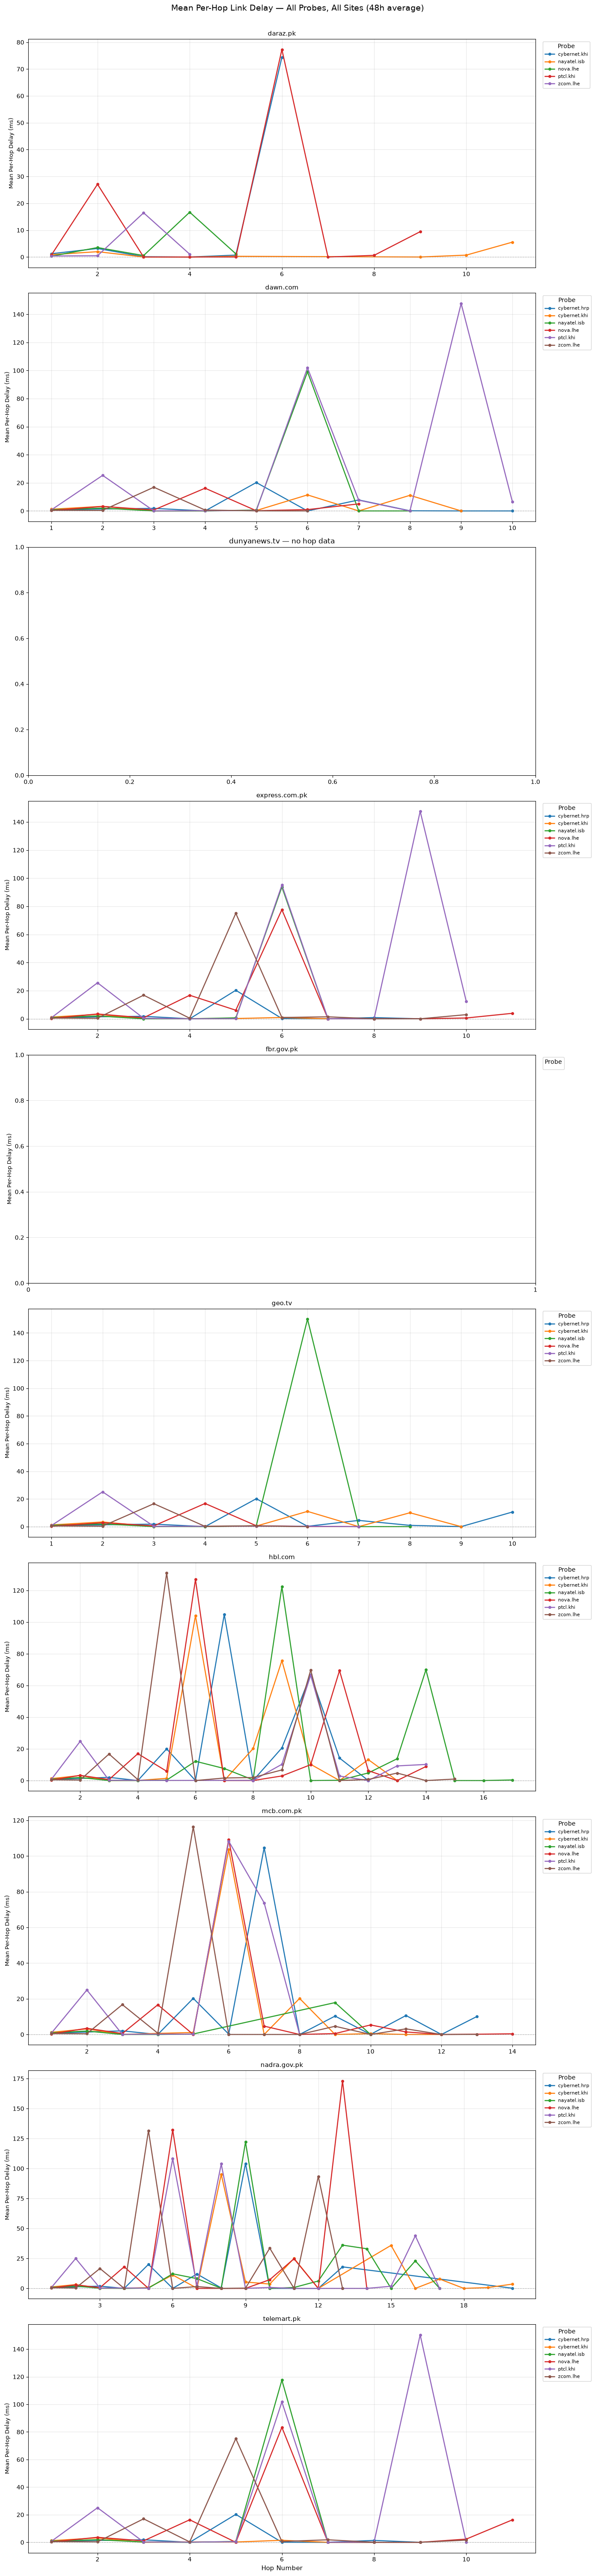

In [ ]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
MAX_HOP     = 20
MIN_SAMPLES = 5

# ── PLOT ALL SITES ────────────────────────────────────────────────────────────
ALL_SITES = sites['target_hostname'].unique()
colors = plt.cm.tab10.colors
probe_label_map = (probes['isp'] + '.' + probes['city_code']).to_dict()

fig, axes = plt.subplots(len(ALL_SITES), 1, figsize=(14, 6 * len(ALL_SITES)))

for ax, TARGET_SITE in zip(axes, ALL_SITES):

    # get site_id
    site_id_matches = sites[sites['target_hostname'] == TARGET_SITE].index
    if len(site_id_matches) == 0:
        ax.set_title(f'{TARGET_SITE} — not found')
        continue
    site_id = site_id_matches[0]

    # get completed trace_ids for this site
    site_trace_ids = df_complete_traces_true_hops[
        df_complete_traces_true_hops['site_id'] == site_id
    ].index

    if len(site_trace_ids) == 0:
        ax.set_title(f'{TARGET_SITE} — no completed traces')
        continue

    # filter hops to just those traces
    site_hops = df_hops[df_hops['trace_id'].isin(site_trace_ids)].copy()

    # merge probe_id onto hops via trace metadata
    site_hops = site_hops.merge(
        df_traces[['probe_id']],
        left_on='trace_id',
        right_index=True,
        how='left'
    )

    # add probe label
    site_hops['probe_name'] = site_hops['probe_id'].map(probe_label_map)

    # filter to reasonable hop range and drop timeouts
    site_hops = site_hops[site_hops['hop_number'] <= MAX_HOP]
    site_hops = site_hops.dropna(subset=['per_hop_contribution'])

    if site_hops.empty:
        ax.set_title(f'{TARGET_SITE} — no hop data')
        continue

    # compute mean per-hop contribution per probe
    mean_per_hop = (
        site_hops
        .groupby(['probe_name', 'hop_number'])['per_hop_contribution']
        .agg(['mean', 'count'])
        .reset_index()
    )

    # filter minimum samples and clip negatives
    mean_per_hop = mean_per_hop[mean_per_hop['count'] >= MIN_SAMPLES]
    mean_per_hop['mean'] = mean_per_hop['mean'].clip(lower=0)

    probes_in_data = sorted(mean_per_hop['probe_name'].unique())

    for i, probe in enumerate(probes_in_data):
        data = mean_per_hop[mean_per_hop['probe_name'] == probe].sort_values('hop_number')
        ax.plot(
            data['hop_number'],
            data['mean'],
            marker='o',
            markersize=4,
            linewidth=1.8,
            label=probe,
            color=colors[i % len(colors)]
        )

    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{TARGET_SITE}', fontsize=11)
    ax.set_ylabel('Mean Per-Hop Delay (ms)', fontsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(title='Probe', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Hop Number', fontsize=11)
plt.suptitle('Mean Per-Hop Link Delay — All Probes, All Sites (48h average)', fontsize=14, y=1.002)
plt.tight_layout()
plt.show()

In [ ]:
site_id = sites[sites['target_hostname'] == 'dawn.com'].index[0]
df_complete_traces_true_hops[
    df_complete_traces_true_hops['site_id'] == site_id
]['probe_id'].value_counts()


probe_id
1015679    192
60223      192
1016036    192
7613       192
1016126    190
1016143     90
Name: count, dtype: int64

In [ ]:

ping_file = '../../experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/fact_ping.csv'
pings = pd.read_csv(ping_file)
pings_filtered = pings[pings['loss_pct'] != 100.0]


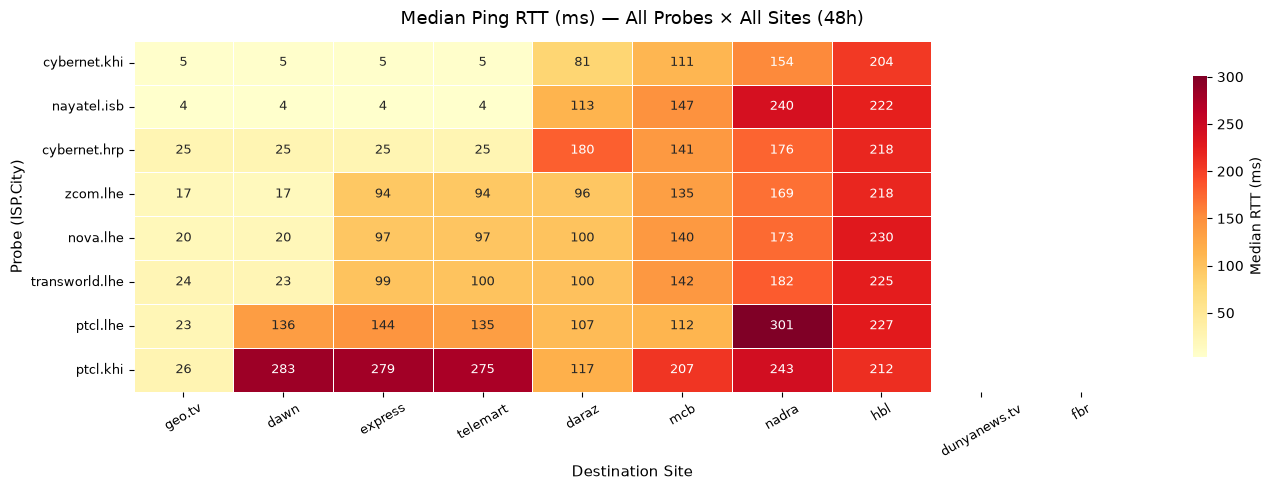


Heatmap data (median RTT ms):
target_hostname  geo.tv   dawn  express  telemart  daraz    mcb  nadra    hbl  dunyanews.tv  fbr
probe_name                                                                                      
cybernet.khi        5.2    5.2      5.2       5.2   80.8  111.2  153.9  203.7           NaN  NaN
nayatel.isb         3.6    3.5      3.5       3.6  113.4  147.3  240.0  222.1           NaN  NaN
cybernet.hrp       24.8   24.8     24.9      24.9  179.9  140.5  176.1  218.5           NaN  NaN
zcom.lhe           17.5   17.3     94.4      94.3   95.8  134.5  169.2  217.8           NaN  NaN
nova.lhe           19.8   20.3     96.5      96.7   99.6  139.7  172.6  230.0           NaN  NaN
transworld.lhe     24.4   23.4     98.8      99.8  100.2  141.8  181.8  224.7           NaN  NaN
ptcl.lhe           22.6  136.3    144.4     135.3  106.6  112.5  301.1  226.7           NaN  NaN
ptcl.khi           26.3  283.0    279.2     275.0  117.3  207.1  243.0  212.1           NaN  NaN

In [ ]:
# ── RTT Heatmap: Probe × Site ─────────────────────────────────────────────────
# Uses ping data (fact_ping.csv) for median RTT per probe-site pair
# Rows = probes, Columns = sites, Color = median RTT (ms)

import seaborn as sns
import numpy as np

# build probe label map
probe_label_map = (probes['isp'] + '.' + probes['city_code']).to_dict()

# merge site hostnames and probe names onto pings
pings_labelled = pings_filtered.copy()
pings_labelled['probe_name'] = pings_labelled['probe_id'].map(probe_label_map)
pings_labelled = pings_labelled.merge(
    sites[['target_hostname']], left_on='site_id', right_index=True, how='left'
)

# compute median RTT per probe-site pair (use rtt_avg since rtt_min can be noisy)
heatmap_data = (
    pings_labelled
    .groupby(['probe_name', 'target_hostname'])['rtt_avg']
    .median()
    .unstack(level='target_hostname')
)

# order probes by overall median RTT (fastest at top)
probe_order = heatmap_data.median(axis=1).sort_values().index
heatmap_data = heatmap_data.loc[probe_order]

# order sites by overall median RTT (easiest/local first)
site_order = heatmap_data.median(axis=0).sort_values().index
heatmap_data = heatmap_data[site_order]

# shorten site names for display
short_sites = {s: s.replace('.com.pk','').replace('.gov.pk','').replace('.pk','').replace('.com','') 
               for s in heatmap_data.columns}
heatmap_data = heatmap_data.rename(columns=short_sites)

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Median RTT (ms)', 'shrink': 0.8},
    annot_kws={'size': 9},
)

ax.set_title('Median Ping RTT (ms) — All Probes × All Sites (48h)', fontsize=13, pad=12)
ax.set_xlabel('Destination Site', fontsize=11)
ax.set_ylabel('Probe (ISP.City)', fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

print("\nHeatmap data (median RTT ms):")
print(heatmap_data.round(1).to_string())

## RTT Heatmap — Key Observations

The heatmap reveals three distinct tiers of performance:

**Locally-served CDN sites (geo.tv, dawn.com):** Cybernet.khi and Nayatel achieve 3-5ms — consistent with local Cloudflare peering via Transworld. PTCL Karachi is a stark outlier at 283ms to dawn.com despite being geographically closest to PIE Karachi, contradicting its claimed local CDN peering.

**Internationally-served Cloudflare (express.com.pk, telemart.pk):** Zcom, Nova, and Transworld cluster around 94-100ms — routed through China Mobile HK. PTCL Karachi again outlier at 275-279ms, routing through Lumen/Level3 via Europe.

**Foreign-hosted content (daraz, mcb, nadra, hbl):** All ISPs show high RTT (80-300ms) reflecting content hosted in Singapore, US, and regional PoPs. PTCL Lahore is notably high for NADRA at 301ms.

**FBR and Dunyanews.tv:** NaN across all probes — both block ICMP, confirming they cannot be measured via traceroute/ping.

The row ordering (fastest to slowest overall) shows Cybernet.khi as the best performer, enabled by its direct DE-CIX Frankfurt and Equinix Singapore peering via the PEACE submarine cable.

In [212]:
# ── Statistics Table: per probe per site ─────────────────────────────────────
# Median RTT, Mean RTT, Packet Loss %, Median Hop Count

import warnings
warnings.filterwarnings('ignore')

probe_label_map = dict(zip(probes.index, probes['isp'] + '.' + probes['city_code']))

# ── Ping stats (RTT + loss) ───────────────────────────────────────────────────
pings_all = pings.copy()  # use full pings including 100% loss rows for loss calc
pings_all['probe_name'] = pings_all['probe_id'].map(probe_label_map)
pings_all = pings_all.merge(
    sites[['target_hostname']], left_on='site_id', right_index=True, how='left'
)

ping_stats = (
    pings_all
    .groupby(['probe_name', 'target_hostname'])
    .agg(
        median_rtt  = ('rtt_avg', 'median'),
        mean_rtt    = ('rtt_avg', 'mean'),
        loss_pct    = ('loss_pct', 'mean'),
    )
    .round(1)
    .reset_index()
)

# ── Hop count stats from traceroutes ─────────────────────────────────────────
hop_counts = df_complete_traces_true_hops.copy()
hop_counts['probe_name'] = hop_counts['probe_id'].map(probe_label_map)
hop_counts = hop_counts.merge(
    sites[['target_hostname']], left_on='site_id', right_index=True, how='left'
)

hop_stats = (
    hop_counts
    .groupby(['probe_name', 'target_hostname'])
    .agg(median_hops = ('max_hops', 'median'))
    .round(1)
    .reset_index()
)

# ── Merge ─────────────────────────────────────────────────────────────────────
stats = ping_stats.merge(hop_stats, on=['probe_name', 'target_hostname'], how='left')

# order by probe and site
site_order = ['geo.tv','dawn.com','express.com.pk','telemart.pk',
              'daraz.pk','mcb.com.pk','nadra.gov.pk','hbl.com',
              'dunyanews.tv','fbr.gov.pk']
probe_order = ['cybernet.khi','nayatel.isb','cybernet.hrp','zcom.lhe',
               'nova.lhe','transworld.lhe','ptcl.lhe','ptcl.khi']

stats['probe_name'] = pd.Categorical(stats['probe_name'], categories=probe_order, ordered=True)
stats['target_hostname'] = pd.Categorical(stats['target_hostname'], categories=site_order, ordered=True)
stats = stats.sort_values(['probe_name','target_hostname'])

print("=== Full Statistics Table ===\n")
print(stats.to_string(index=False))

# ── Pivot for paper-ready view ────────────────────────────────────────────────
print("\n\n=== Median RTT (ms) — pivot ===")
pivot_rtt = stats.pivot(index='probe_name', columns='target_hostname', values='median_rtt')
print(pivot_rtt.round(1).to_string())

print("\n\n=== Mean Packet Loss (%) — pivot ===")
pivot_loss = stats.pivot(index='probe_name', columns='target_hostname', values='loss_pct')
print(pivot_loss.round(1).to_string())

print("\n\n=== Median Hop Count — pivot ===")
pivot_hops = stats.pivot(index='probe_name', columns='target_hostname', values='median_hops')
print(pivot_hops.round(1).to_string())

# save to CSV
stats.to_csv('stats_table.csv', index=False)
print("\nSaved to stats_table.csv")

=== Full Statistics Table ===

    probe_name target_hostname  median_rtt  mean_rtt  loss_pct  median_hops
  cybernet.khi          geo.tv         5.2      15.7       0.1          7.0
  cybernet.khi        dawn.com         5.2      15.6       0.0          7.0
  cybernet.khi  express.com.pk         5.2       5.3       0.0          7.0
  cybernet.khi     telemart.pk         5.2       5.2       0.0          7.0
  cybernet.khi        daraz.pk        80.8      80.9       0.1         12.0
  cybernet.khi      mcb.com.pk       111.2     111.1       0.0         12.0
  cybernet.khi    nadra.gov.pk       153.9     159.4       0.4         16.0
  cybernet.khi         hbl.com       203.7     203.6       0.0         13.0
  cybernet.khi    dunyanews.tv         NaN       NaN     100.0          NaN
  cybernet.khi      fbr.gov.pk         NaN       NaN     100.0          NaN
   nayatel.isb          geo.tv         3.6       3.7       0.7          8.0
   nayatel.isb        dawn.com         3.5       3.6     

In [213]:
# ── Focused Statistics Tables for Paper ──────────────────────────────────────
# Table 1: dawn.com (local CDN — shows ISP peering gap)
# Table 2: hbl.com (foreign hosted — shows offshore penalty)

import warnings
warnings.filterwarnings('ignore')

probe_label_map = dict(zip(probes.index, probes['isp'] + '.' + probes['city_code']))

# ── ping stats ────────────────────────────────────────────────────────────────
pings_all = pings.copy()
pings_all['probe_name'] = pings_all['probe_id'].map(probe_label_map)
pings_all = pings_all.merge(
    sites[['target_hostname']], left_on='site_id', right_index=True, how='left'
)

ping_stats = (
    pings_all
    .groupby(['probe_name', 'target_hostname'])
    .agg(
        median_rtt = ('rtt_avg', 'median'),
        loss_pct   = ('loss_pct', 'mean'),
    )
    .round(1)
    .reset_index()
)

# ── hop count ─────────────────────────────────────────────────────────────────
hop_counts = df_complete_traces_true_hops.copy()
hop_counts['probe_name'] = hop_counts['probe_id'].map(probe_label_map)
hop_counts = hop_counts.merge(
    sites[['target_hostname']], left_on='site_id', right_index=True, how='left'
)

hop_stats = (
    hop_counts
    .groupby(['probe_name', 'target_hostname'])
    .agg(median_hops=('max_hops', 'median'))
    .round(0)
    .reset_index()
)

stats = ping_stats.merge(hop_stats, on=['probe_name', 'target_hostname'], how='left')

probe_order = ['cybernet.khi', 'nayatel.isb', 'cybernet.hrp', 'zcom.lhe',
               'nova.lhe', 'transworld.lhe', 'ptcl.lhe', 'ptcl.khi']

stats['probe_name'] = pd.Categorical(stats['probe_name'], categories=probe_order, ordered=True)
stats = stats.sort_values('probe_name')

# ── Table 1: dawn.com ─────────────────────────────────────────────────────────
dawn = stats[stats['target_hostname'] == 'dawn.com'][
    ['probe_name', 'median_rtt', 'loss_pct', 'median_hops']
].copy()
dawn.columns = ['Probe', 'Median RTT (ms)', 'Loss (%)', 'Median Hops']

print("Table 1: dawn.com (Cloudflare, locally served)")
print("=" * 55)
print(dawn.to_string(index=False))

# ── Table 2: hbl.com ──────────────────────────────────────────────────────────
hbl = stats[stats['target_hostname'] == 'hbl.com'][
    ['probe_name', 'median_rtt', 'loss_pct', 'median_hops']
].copy()
hbl.columns = ['Probe', 'Median RTT (ms)', 'Loss (%)', 'Median Hops']

print("\nTable 2: hbl.com (Incapsula, New Jersey US)")
print("=" * 55)
print(hbl.to_string(index=False))

# ── Save CSVs ─────────────────────────────────────────────────────────────────
dawn.to_csv('table_dawn.csv', index=False)
hbl.to_csv('table_hbl.csv', index=False)
print("\nSaved table_dawn.csv and table_hbl.csv")

Table 1: dawn.com (Cloudflare, locally served)
         Probe  Median RTT (ms)  Loss (%)  Median Hops
  cybernet.khi              5.2       0.0          7.0
   nayatel.isb              3.5       0.4          8.0
  cybernet.hrp             24.8       0.1          9.0
      zcom.lhe             17.3       0.1          6.0
      nova.lhe             20.3       0.6          7.0
transworld.lhe             23.4       0.3          NaN
      ptcl.lhe            136.3      74.5          NaN
      ptcl.khi            283.0       6.0         10.0

Table 2: hbl.com (Incapsula, New Jersey US)
         Probe  Median RTT (ms)  Loss (%)  Median Hops
  cybernet.khi            203.7       0.0         13.0
   nayatel.isb            222.1       0.6         19.0
  cybernet.hrp            218.5       0.2         14.0
      zcom.lhe            217.8       0.2         15.0
      nova.lhe            230.0       0.7         16.0
transworld.lhe            224.7       0.3          NaN
      ptcl.lhe            22

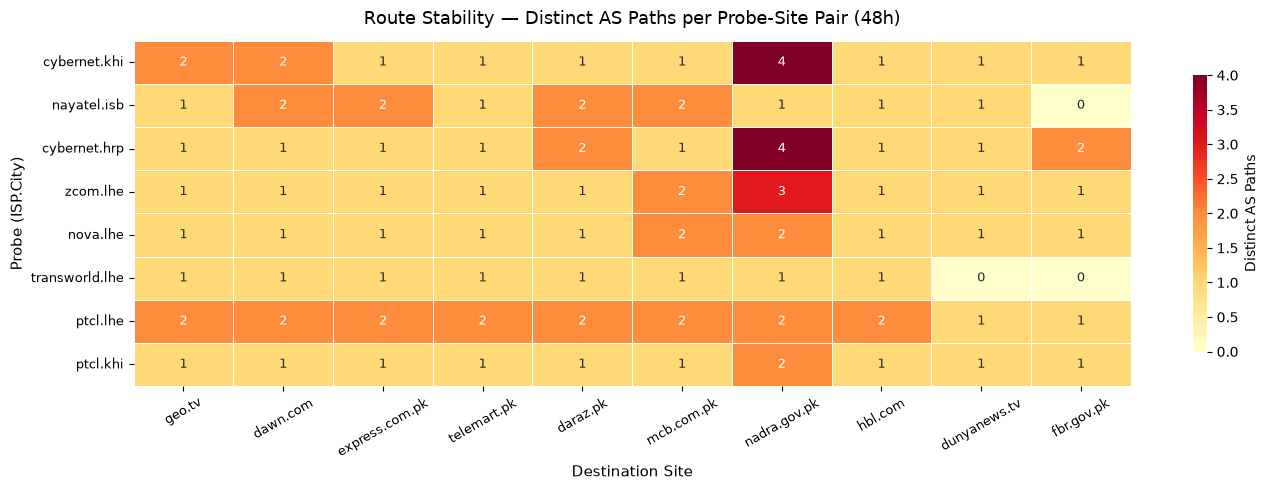


Distinct paths summary:
probe_name
cybernet.khi      1.5
nayatel.isb       1.3
cybernet.hrp      1.5
zcom.lhe          1.3
nova.lhe          1.2
transworld.lhe    0.8
ptcl.lhe          1.8
ptcl.khi          1.1
Name: distinct_paths, dtype: float64


In [218]:
# ── Route Stability: distinct AS paths per probe per site ─────────────────────

probe_label_map = dict(zip(probes.index, probes['isp'] + '.' + probes['city_code']))

# load fact_trace which has asns_in_path
trace_file = '../../experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/fact_trace.csv'
fact_trace = pd.read_csv(trace_file)

fact_trace['probe_name'] = fact_trace['probe_id'].map(probe_label_map)
fact_trace = fact_trace.merge(
    sites[['target_hostname']], left_on='site_id', right_index=True, how='left'
)

# count distinct AS paths per probe-site pair
stability = (
    fact_trace
    .groupby(['probe_name', 'target_hostname'])['asns_in_path']
    .nunique()
    .reset_index()
    .rename(columns={'asns_in_path': 'distinct_paths'})
)

# pivot for heatmap
probe_order = ['cybernet.khi','nayatel.isb','cybernet.hrp','zcom.lhe',
               'nova.lhe','transworld.lhe','ptcl.lhe','ptcl.khi']
site_order  = ['geo.tv','dawn.com','express.com.pk','telemart.pk',
               'daraz.pk','mcb.com.pk','nadra.gov.pk','hbl.com',
               'dunyanews.tv','fbr.gov.pk']

stability['probe_name'] = pd.Categorical(stability['probe_name'], categories=probe_order, ordered=True)
stability['target_hostname'] = pd.Categorical(stability['target_hostname'], categories=site_order, ordered=True)

pivot = stability.pivot(index='probe_name', columns='target_hostname', values='distinct_paths')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot, ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Distinct AS Paths', 'shrink': 0.8},
    annot_kws={'size': 9}
)
ax.set_title('Route Stability — Distinct AS Paths per Probe-Site Pair (48h)', fontsize=13, pad=12)
ax.set_xlabel('Destination Site', fontsize=11)
ax.set_ylabel('Probe (ISP.City)', fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

print("\nDistinct paths summary:")
print(stability.groupby('probe_name')['distinct_paths'].mean().round(1))

Route stability across the 48-hour measurement window was high for all probe-ISP pairs. The vast majority of probe-site combinations showed only one distinct AS path throughout the experiment, confirming that the latency disparities observed are structural and persistent rather than the result of transient congestion or routing oscillation. The primary exception is NADRA, which uses Akamai's anycast infrastructure — Cybernet Karachi and Cybernet Haripur each observed four distinct paths to NADRA, reflecting Akamai's load-balanced anycast routing rather than ISP-level instability. PTCL Lahore showed two distinct paths to most destinations, suggesting occasional switching between its upstream transit providers over the measurement period. Overall, the low path diversity confirms that our findings reflect stable, long-term routing policies rather than transient network conditions.